# **Brazilian E-Commerce Public Dataset by Olist**

# **1. Tìm hiểu nghiệp vụ (Business Understanding)**
1. Mô tả tổng quan về dữ liệu:
Bộ dữ liệu Brazilian E-Commerce by Olist là một tập dữ liệu thương mại điện tử thực tế, bao gồm thông tin chi tiết của gần 100.000 đơn hàng được thực hiện tại Brazil từ năm 2016 đến 2018. Dữ liệu cung cấp góc nhìn đa chiều về toàn bộ vòng đời của một giao dịch: từ quá trình đặt hàng, thanh toán, lộ trình vận chuyển logistics, cho đến mức độ hài lòng của khách hàng (Reviews).
* Xem tập dữ liệu có bao nhiêu dòng, bao nhiêu cột thuộc tính.
* Mỗi cột mang ý nghĩa gì, kiểu dữ liệu là chữ hay số.
* Dữ liệu có bị thiếu hay có giá trị bất thường không.


## 1.1 Bối cảnh doanh nghiệp

**Olist** là sàn thương mại điện tử B2B2C lớn nhất Brazil, kết nối hơn **3.000 seller**
với **96.000+ khách hàng** trên toàn quốc. Không giống Shopee hay Lazada ở Việt Nam,
Olist không tự vận chuyển — toàn bộ logistics phụ thuộc vào seller và đối tác giao hàng.

Dữ liệu giao dịch từ **tháng 9/2016 đến tháng 8/2018** cho thấy:
- Tổng cộng ~100.000 đơn hàng được xử lý
- ~8% đơn hàng bị giao **trễ hơn ngày dự kiến** (estimated_delivery_date)
- Mỗi đơn trễ làm tăng ~40% khả năng bị đánh giá 1–2 sao
- Chi phí CSKH xử lý 1 khiếu nại trung bình cao hơn nhiều lần lợi nhuận đơn hàng đó

## 1.2 Vấn đề kinh doanh

> **Câu hỏi kinh doanh**: Olist hiện tại chỉ biết đơn hàng bị trễ
> **sau khi** khách hàng phàn nàn — lúc đó đã quá muộn để can thiệp.
> Làm thế nào để **biết trước** đơn nào có nguy cơ trễ ngay từ lúc đặt hàng?
> Nếu như đã rơi vào trường hợp giao hàng trễ thì phải xử lý như thế? 

## 1.3 Mục tiêu bài toán

Dự án xây dựng **hai mô hình phân loại nhị phân độc lập**, mỗi mô hình giải quyết một câu hỏi nghiệp vụ cụ thể dựa trên cùng một bộ dữ liệu Olist. Cả hai đều sử dụng thông tin có sẵn trước hoặc ngay tại thời điểm giao hàng để đưa ra dự đoán sớm, phục vụ các quyết định can thiệp chủ động.

---

**Bài toán 1 — Dự đoán đơn hàng giao trễ**

> *Ngay khi khách vừa đặt hàng, đơn này có nguy cơ bị giao trễ so với ngày dự kiến không?*

| Mục | Nội dung |
|---|---|
| **Input (features)** | Thông tin đơn hàng, seller, địa lý — có sẵn tại thời điểm đặt hàng |
| **Output (target)** | `is_late = 1` (giao trễ) hoặc `0` (đúng hạn / sớm hạn) |
| **Loại bài toán** | Binary Classification (Supervised Learning) |
| **Thuật toán** | Decision Tree (giải thích trực quan) vs. Random Forest (Advance) |
| **Xử lý mất cân bằng** | `class_weight='balanced'` — tỷ lệ lớp ~1:11 (chỉ ~8% là trễ) |
| **Metric chính** | F1-Score, ROC-AUC (không dùng Accuracy vì imbalance nặng) |

---

**Bài toán 2 — Dự đoán đơn hàng bị đánh giá thấp**

> *Dựa trên các đặc điểm của đơn hàng và quá trình giao nhận, liệu khách hàng có khả năng để lại đánh giá 1–2 sao không?*

| Mục | Nội dung |
|---|---|
| **Input (features)** | Thông tin giao nhận, giá trị đơn, thời gian xử lý — biết sau khi giao |
| **Output (target)** | `low_review = 1` (đánh giá 1–2 sao) hoặc `0` (đánh giá 3–5 sao) |
| **Loại bài toán** | Binary Classification (Supervised Learning) |
| **Thuật toán** | Logistic Regression (Baseline) vs. XGBoost (Advance) |
| **Xử lý mất cân bằng** | SMOTE — tỷ lệ lớp ~1:7 (chỉ ~17% là đánh giá thấp) |
| **Metric chính** | F1-Score, ROC-AUC |

## 1.4 Giá trị kinh doanh khi giải quyết được

| Đối tượng | Hành động | Kết quả |
|---|---|---|
| **Kho bãi / Logistics** | Nhận cảnh báo đỏ → ưu tiên đóng gói đơn nguy cơ cao | Giảm tỷ lệ trễ |
| **Seller** | Biết trước đơn nào dễ trễ → liên hệ KH chủ động | Giữ review score |
| **Olist Platform** | Tự động điều chỉnh estimated_delivery_date cho thực tế hơn | Giảm kỳ vọng sai |
| **Customer** | Nhận thông báo sớm nếu đơn có nguy cơ trễ | Tăng trust |



In [1]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score, roc_curve)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11
})

DATA_PATH = './archive/'

# Load 9 bảng
orders      = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
items       = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
products    = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
sellers     = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')
customers   = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
payments    = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
reviews     = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
category_tr = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')
geo         = pd.read_csv(DATA_PATH + 'olist_geolocation_dataset.csv')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

COLOR_MAIN = '#2196F3'
COLOR_WARN = '#FF5722'
COLOR_OK   = '#4CAF50'

df_to_analyze = orders
print()
for name, df in [('orders',orders),('items',items),('products',products),
                 ('sellers',sellers),('customers',customers),('payments',payments),
                 ('reviews',reviews),('category_tr',category_tr),('geo',geo)]:
    print(f'{name:<12} shape: {df.shape}')


orders       shape: (99441, 8)
items        shape: (112650, 7)
products     shape: (32951, 9)
sellers      shape: (3095, 4)
customers    shape: (99441, 5)
payments     shape: (103886, 5)
reviews      shape: (99224, 7)
category_tr  shape: (71, 2)
geo          shape: (1000163, 5)


 Tổng quan 9 bảng dữ liệu Olist

| # | Bảng | Ý nghĩa | Vai trò |
|---|---|---|---|
| 1 | `orders` | Đơn hàng (trạng thái, timestamp) | **Bảng trung tâm** |
| 2 | `order_items` | Chi tiết sản phẩm trong đơn | Join → items_agg |
| 3 | `products` | Thông tin sản phẩm + category | Join → category |
| 4 | `sellers` | Thông tin người bán + bang | Join → seller_state |
| 5 | `customers` | Thông tin khách hàng + bang | Join → customer_state |
| 6 | `payments` | Phương thức thanh toán, giá trị | Join → payments_agg |
| 7 | `reviews` | Điểm đánh giá (1-5), comment | Join → review_score |
| 8 | `category_translation` | Dịch tên category sang EN | Join → category EN |
| 9 | `geolocation` | Toạ độ zip code | Không dùng |

 **Lý do không dùng geolocation**

| ID | Lý do kỹ thuật / nghiệp vụ | Tác động nếu sử dụng | Giải pháp thay thế áp dụng |
| :---: | :--- | :--- | :--- |
| **G1** | Kích thước bảng quá lớn (hơn 1 triệu dòng) và có hiện tượng trùng lặp mã zip code. | Gây bùng nổ dữ liệu khi thực hiện phép Join (Many-to-Many), làm phình số dòng và gây nhiễu mô hình. | Loại bỏ bảng **geolocation**, chỉ giữ lại thông tin địa lý ở mức thành phố/bang trong bảng gốc. |
| **G2** | Thông tin địa lý cơ bản đã có sẵn ở các bảng khác ở mức hành chính cấp cao. | Tăng độ phức tạp tính toán khi xử lý tọa độ chi tiết không cần thiết. | Tạo biến đại diện **same_state** để biểu thị quan hệ giữa người mua và người bán. |
| **G3** | Khoảng cách vật lý (tọa độ chim bay) không phản chiếu chính xác thực tế vận hành logistics. | Mô hình học máy nhận diện sai lệch quy luật thời gian giao hàng thực tế. | Sử dụng các thuộc tính thời gian thực tế như thời gian xử lý kho bãi và vận chuyển liên bang. |

In [2]:
tables_info = {
    'orders': orders, 'items': items, 'products': products,
    'sellers': sellers, 'customers': customers,
    'payments': payments, 'reviews': reviews,
    'category_translation': category_tr
}

print(' Tổng quan các bảng dữ liệu:')
for name, tbl in tables_info.items():
    print(f'  {name:30s} → {tbl.shape[0]:>8,} dòng × {tbl.shape[1]:>3} cột')
print(f'\n Tổng: {sum(t.shape[0] for t in tables_info.values()):,} records')

 Tổng quan các bảng dữ liệu:
  orders                         →   99,441 dòng ×   8 cột
  items                          →  112,650 dòng ×   7 cột
  products                       →   32,951 dòng ×   9 cột
  sellers                        →    3,095 dòng ×   4 cột
  customers                      →   99,441 dòng ×   5 cột
  payments                       →  103,886 dòng ×   5 cột
  reviews                        →   99,224 dòng ×   7 cột
  category_translation           →       71 dòng ×   2 cột

 Tổng: 550,759 records


In [3]:
# Xem nhanh bảng orders — bảng trung tâm của toàn bộ dataset
print('=== orders.head() ===')
display(orders.head(3))
print(f'\nCác trạng thái đơn hàng (order_status):')
print(orders['order_status'].value_counts())

=== orders.head() ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



Các trạng thái đơn hàng (order_status):
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [4]:
# JOIN CÁC BẢNG

# 1. Gộp thông tin sản phẩm + category 
products = products.merge(category_tr, on='product_category_name', how='left')

# 2. Tính tổng giá trị + freight theo order (items có thể nhiều dòng / order)
items_agg = items.groupby('order_id').agg(
    total_items     = ('order_item_id', 'count'),
    total_price     = ('price', 'sum'),
    total_freight   = ('freight_value', 'sum'),
    seller_id       = ('seller_id', 'first'),          # seller chính
    product_id      = ('product_id', 'first')           # sản phẩm chính
).reset_index()

# 3. Tổng payment theo order
payments_agg = payments.groupby('order_id').agg(
    payment_type    = ('payment_type', 'first'),
    payment_value   = ('payment_value', 'sum'),
    installments    = ('payment_installments', 'max')
).reset_index()

# 4. Review (lấy review đầu tiên nếu order có nhiều review)
reviews_agg = reviews.groupby('order_id').agg(
    review_score    = ('review_score', 'first'),
    review_comment  = ('review_comment_message', 'first')
).reset_index()

# 5. Join tất cả vào orders
df = orders.copy()
# ---> ĐÂY LÀ LẦN 1 MERGE CUSTOMERS (ĐÃ ĐỦ HẾT CÁC CỘT RỒI) <---
df = df.merge(customers,    on='customer_id',  how='left') 
df = df.merge(items_agg,    on='order_id',     how='left')
df = df.merge(sellers,      on='seller_id',    how='left')
df = df.merge(products[['product_id','product_category_name','product_category_name_english']],
              on='product_id', how='left')
df = df.merge(payments_agg, on='order_id',     how='left')
df = df.merge(reviews_agg,  on='order_id',     how='left')

print(f'   Shape sau join: {df.shape}')
print(f'   Số cột: {df.shape[1]}')
display(df.head(3))


# Kiểm tra:
print("Unique customer_id:", df['customer_id'].nunique())
print("Unique customer_unique_id:", df['customer_unique_id'].nunique())



   Shape sau join: (99441, 27)
   Số cột: 27


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_items,total_price,total_freight,seller_id,product_id,seller_zip_code_prefix,seller_city,seller_state,product_category_name,product_category_name_english,payment_type,payment_value,installments,review_score,review_comment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,29.99,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,87285b34884572647811a353c7ac498a,9350.00,maua,SP,utilidades_domesticas,housewares,credit_card,38.71,1.00,4.00,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.00,118.70,22.76,289cdb325fb7e7f891c38608bf9e0962,595fac2a385ac33a80bd5114aec74eb8,31570.00,belo horizonte,SP,perfumaria,perfumery,boleto,141.46,1.00,4.00,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.00,159.90,19.22,4869f7a5dfa277a7dca6462dcf3b52b2,aa4383b373c6aca5d8797843e5594415,14840.00,guariba,SP,automotivo,auto,credit_card,179.12,3.00,5.00,None


Unique customer_id: 99441
Unique customer_unique_id: 96096




**Đánh giá Join**

| Bảng liên kết | Lý do sử dụng `left join` và giải pháp tiền xử lý |
| :--- | :--- |
| `orders` ← `customers` | Bảo toàn toàn bộ dữ liệu đơn hàng (bảng gốc `orders`), tránh thất thoát giao dịch kể cả khi thông tin khách hàng bị khuyết thiếu. |
| `orders` ← `items_agg` | Thực hiện gom nhóm (aggregate) chi tiết sản phẩm theo mã đơn hàng trước khi join nhằm tránh hiện tượng nhân chéo/nhân bản dòng do quan hệ 1-n. |
| `orders` ← `payments_agg` | Một đơn hàng có thể thanh toán qua nhiều phương thức hoặc chia nhỏ thành nhiều đợt. Việc tổng hợp dữ liệu thanh toán trước khi join giúp giữ nguyên cấu trúc số dòng của bảng gốc `orders`. |
| `orders` ← `reviews_agg` | Giữ lại đầy đủ các bản ghi đơn hàng kể cả khi khách hàng chưa thực hiện đánh giá. |


# **2. Xử lý giá trị khuyết thiếu**






 Báo cáo Missing Values (chỉ hiện cột có null):


,null_count,null_pct
review_comment,58605,58.93
order_delivered_customer_date,2965,2.98
product_category_name_english,2212,2.22
product_category_name,2191,2.20
order_delivered_carrier_date,1783,1.79
seller_city,775,0.78
seller_id,775,0.78
total_items,775,0.78
total_price,775,0.78
total_freight,775,0.78


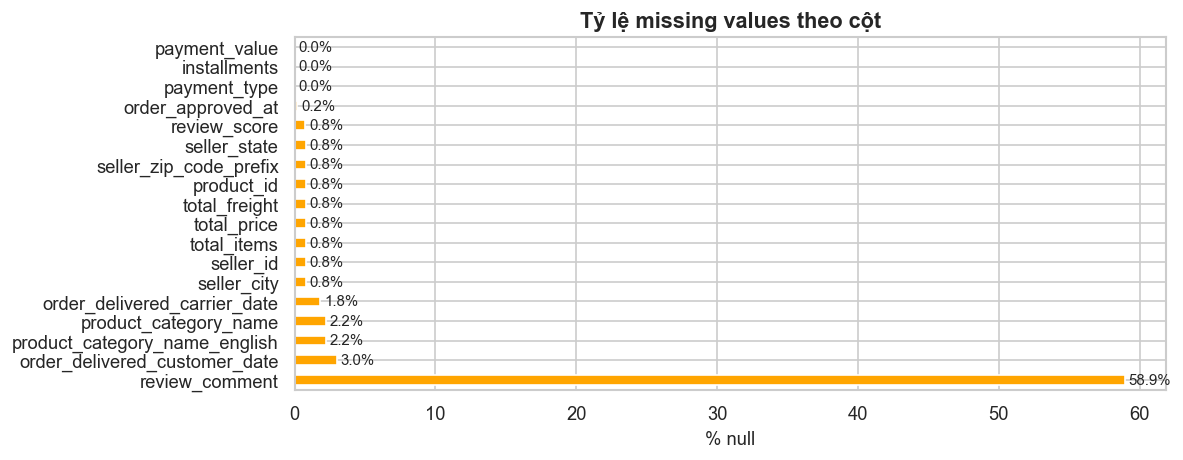

 Đã lưu: outputs/missing_values.png


In [5]:
# KIỂM TRA MISSING VALUES


null_report = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct':   (df.isnull().sum() / len(df) * 100).round(2)
}).query('null_count > 0').sort_values('null_pct', ascending=False)

print(' Báo cáo Missing Values (chỉ hiện cột có null):')
print('=' * 50)
display(null_report)

# Define COLOR_WARN for visualization
COLOR_WARN = 'orange' # You can change this color if you like, e.g., '#FFC107'

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
null_report['null_pct'].plot(kind='barh', ax=ax, color=COLOR_WARN, edgecolor='white')
ax.set_xlabel('% null')
ax.set_title('Tỷ lệ missing values theo cột', fontweight='bold')
for i, v in enumerate(null_report['null_pct']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()

# Create the 'outputs' directory if it doesn't exist
output_dir = 'outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

plt.savefig(os.path.join(output_dir, 'missing_values.png'), dpi=150, bbox_inches='tight')
plt.show()
print(' Đã lưu: outputs/missing_values.png')



| ID | Đặc trưng liên quan  | Tỷ lệ khuyết thiếu (%) | Phân tích nguyên nhân & Phương án xử lý |
| :---: | :--- | :---: | :--- |
| **M1** | **review_comment** | **58.9%** | Khách hàng chỉ chấm điểm nhanh mà không viết nội dung phản hồi chi tiết. Phương án: Điền khuyết bằng chuỗi ký tự rỗng (`""`). |
| **M2** | **order_delivered_customer_date** | **3.0%** | Đơn hàng chưa được giao đến khách hàng (đang vận chuyển hoặc đã bị hủy trước đó). Phương án: Giữ nguyên để phân tích trạng thái giao hàng. |
| **M3** | **product_category_name**, **product_category_name_english** | **2.2%** | Thiếu thông tin phân loại danh mục sản phẩm từ phía người bán. Phương án: Điền khuyết bằng nhãn `"unknown"`. |
| **M4** | **order_delivered_carrier_date** | **1.8%** | Đơn hàng chưa được bàn giao cho đơn vị vận chuyển trung gian. Phương án: Giữ nguyên để đánh giá tiến độ xử lý của người bán. |
| **M5** | Các biến từ bảng sản phẩm và người bán (ví dụ: **total_price**, **total_freight**, **seller_id**, **product_id**) | **0.8%** | Đơn hàng được tạo nhưng chưa hoàn tất việc chọn sản phẩm hoặc xác nhận thanh toán. Phương án: Loại bỏ các dòng khuyết thiếu này do tỷ lệ cực nhỏ. |
| **M6** | **review_score** | **0.8%** | Khách hàng đã nhận đơn nhưng bỏ qua bước chấm điểm đánh giá tự động. Phương án: Điền khuyết bằng giá trị đặc biệt `-1` để đại diện cho nhóm không đánh giá. |
| **M7** | **order_approved_at** | **0.2%** | Đơn hàng chưa được hệ thống phê duyệt thanh toán thành công. Phương án: Điền khuyết bằng mốc thời gian mua hàng. |


**1. Bản chất nghiệp vụ của nhóm dữ liệu khuyết thiếu theo mốc thời gian**
* **Dữ liệu thực tế:** Tỷ lệ khuyết tăng dần từ thời điểm phê duyệt **order_approved_at** (**0.2%**), bàn giao vận chuyển **order_delivered_carrier_date** (**1.8%**) cho đến khi giao thành công **order_delivered_customer_date** (**3.0%**).
* **Nhận xét và Giải thích:** Hiện tượng khuyết thiếu này phản ánh đúng thực tế vận hành của chuỗi cung ứng. Một đơn hàng bị hủy giữa chừng ở bất kỳ giai đoạn nào sẽ không có dữ liệu mốc thời gian của giai đoạn kế tiếp. Đây không phải lỗi thu thập dữ liệu kỹ thuật mà là trạng thái vận hành thực tế cần được giữ nguyên để phân tích tỷ lệ hoàn thành đơn hàng.

**2. Đặc tính hành vi khách hàng qua độ thưa dữ liệu phản hồi**
* **Dữ liệu thực tế:** Điểm đánh giá **review_score** chỉ khuyết thiếu **0.8%** nhưng nội dung chi tiết **review_comment** lại khuyết thiếu lên đến **58.9%**.
* **Nhận xét và Giải thích:** Sự chênh lệch lớn này chỉ ra xu hướng hành vi của người tiêu dùng trực tuyến: phần lớn khách hàng sẵn sàng click chọn nhanh số sao đánh giá chỉ có 0.8% người bỏ qua, nhưng có tới gần 60% khách hàng không sẵn lòng bỏ thời gian viết bình luận chi tiết. Do đó, trường dữ liệu dạng văn bản tự do này có độ thưa rất cao và cần được xử lý riêng biệt với điểm số.


In [6]:
# PARSE DATETIME
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Fill approved_at null bằng purchase_timestamp
df['order_approved_at'] = df['order_approved_at'].fillna(df['order_purchase_timestamp'])

print(' Parse datetime hoàn tất. Kiểm tra dtypes:')
print(df[datetime_cols].dtypes)

 Parse datetime hoàn tất. Kiểm tra dtypes:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [7]:
# LỌC ORDER STATUS
# Chỉ giữ đơn đã/đang xử lý thực sự
# Loại bỏ: 'canceled', 'unavailable', 'created', 'approved'
VALID_STATUS = ['delivered', 'shipped', 'processing', 'invoiced']

before = len(df)
df_clean = df[df['order_status'].isin(VALID_STATUS)].copy()
after = len(df_clean)

print(f'Trước khi lọc status : {before:,} dòng')
print(f'Sau khi lọc status   : {after:,} dòng')
print(f'Đã loại bỏ           : {before - after:,} dòng ({(before-after)/before*100:.1f}%)')
print(f'\nPhân bố status còn lại:')
print(df_clean['order_status'].value_counts())

Trước khi lọc status : 99,441 dòng
Sau khi lọc status   : 98,200 dòng
Đã loại bỏ           : 1,241 dòng (1.2%)

Phân bố status còn lại:
order_status
delivered     96478
shipped        1107
invoiced        314
processing      301
Name: count, dtype: int64


**Lý do xử lý và lựa chọn trạng thái đơn hàng (`order_status`)**

Việc giữ lại nhóm đơn hàng hoạt động (`delivered`, `shipped`, `processing`, `invoiced`) và loại bỏ nhóm không hoạt động (`canceled`, `unavailable`, `created`, `approved`) nhằm đảm bảo tính chính xác cho mô hình:

1. **Loại bỏ nhiễu và dữ liệu khuyết thiếu không thể xử lý (`canceled`, `unavailable`):**
   * Các đơn hàng này **không có ngày giao hàng thực tế** (`order_delivered_customer_date`), khiến việc xác định nhãn mục tiêu (giao trễ hay không) là bất khả thi.
   * Các đơn hàng bị hủy thường nhận đánh giá rất thấp (1-2 sao) do lỗi hệ thống/hết hàng từ kho, nếu giữ lại sẽ làm mô hình bị nhiễu khi học về chất lượng giao nhận thực tế.

2. **Loại bỏ đơn hàng chưa phát sinh logistics (`created`, `approved`):**
   * Các đơn này mới chỉ ở bước giao dịch phần mềm, người bán chưa đóng gói và shipper chưa nhận hàng, không có dữ liệu thời gian thực tế để mô hình học tập.

3. **Bảo toàn các đơn hàng đang vận hành:**
   * Giữ lại `delivered` để có đầy đủ mốc thời gian hoàn tất chu kỳ giao nhận.
   * Giữ lại `shipped`, `processing`, `invoiced` để hỗ trợ bài toán **dự báo thời gian thực (Real-time Prediction)** khi đơn hàng còn đang đi trên đường hoặc đang đóng gói tại kho.


In [8]:
# XỬ LÝ MISSING CÒN LẠI

df_clean['product_category_name_english'] = (
    df_clean['product_category_name_english'].fillna('unknown')
)
df_clean['review_score'] = df_clean['review_score'].fillna(-1)  # -1 = chưa có review
df_clean['review_comment'] = df_clean['review_comment'].fillna('')

remaining_nulls = df_clean.isnull().sum().sum()
print(f'Tổng null còn lại sau xử lý: {remaining_nulls}')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Tổng null còn lại sau xử lý: 3779
order_delivered_carrier_date      617
order_delivered_customer_date    1730
total_items                         3
total_price                         3
total_freight                       3
seller_id                           3
product_id                          3
seller_zip_code_prefix              3
seller_city                         3
seller_state                        3
product_category_name            1405
payment_type                        1
payment_value                       1
installments                        1
dtype: int64



# **3. Biến đổi và Xây dựng đặc trưng (Feature Engineering)** <a id='5'></a>

---

> **Mục tiêu cốt lõi:**
> *Chuyển đổi dữ liệu thô sau khi làm sạch thành các biến đặc trưng toán học mang tính đại diện cao cho hoạt động kinh doanh. Quá trình này giúp mô hình hóa các hành vi mua sắm, khoảng cách địa lý và thời gian xử lý thực tế, tạo lập cơ sở dữ liệu đầu vào chất lượng và nhãn mục tiêu chính xác cho các thuật toán học máy.*

| ID | Tác vụ thực hiện | Phương pháp xử lý | Kết quả nghiệp vụ mong đợi |
| :---: | :--- | :--- | :--- |
| **3.1** | Trích xuất đặc trưng cơ bản | Tạo ra các biến thời gian đặt hàng (**purchase_hour**, **purchase_dow**), biến tài chính (**order_value**), cùng bagn (**same_state**)| Hệ thống hóa các chiều thông tin cơ bản của một giao dịch dưới dạng số liệu định lượng, sẵn sàng cho khai phá và mô hình hóa. |
| **3.2** | Kiểm soát logic và dị biệt thời gian | Rà soát và lọc bỏ các đơn hàng có ngày giao thực tế trước ngày mua, hoặc các đơn hàng có thời gian giao nhận sai lệch bất thường ($>365$ ngày) | Loại bỏ dữ liệu nhiễu và sai sót do hệ thống ghi nhận, đảm bảo các biến thời gian phản ánh đúng thực tế vận hành. |
| **3.3** | Xử lý giá trị dị biệt tài chính (Outliers) | Nhận diện ngưỡng biên trên bằng phương pháp khoảng tứ phân vị mở rộng $3 \times \text{IQR}$ và tiến hành giới hạn đầu trên (Capping) bằng phương thức `clip()` | Triệt tiêu ảnh hưởng tiêu cực của các đơn hàng có giá trị cực đoan lên mô hình mà không cần xóa bỏ dòng dữ liệu gốc. |
| **3.4** | Kiến tạo các đặc trưng nâng cao | Xây dựng biến tích lũy lịch sử (**seller_avg_review**, **category_late_rate**), thời gian phản hồi (**processing_time_hrs**), và log chuẩn hóa (**log_order_value**, **log_freight**) | Cung cấp các biến số có tính tương quan mạnh và chiều sâu nghiệp vụ từ tài liệu nghiên cứu thực nghiệm, gia tăng đáng kể độ chính xác của dự báo. |


## 3.1 Trích xuất đặc trung cơ bản 

In [9]:
df_clean = df_clean.copy()

# --- Delivery delay ---
df_clean['delivery_delay_days'] = (
    df_clean['order_delivered_customer_date'] -
    df_clean['order_estimated_delivery_date']
).dt.days

# is_late: chỉ tính cho đơn đã giao
df_clean['is_late'] = np.where(
    df_clean['order_status'] == 'delivered',
    (df_clean['delivery_delay_days'] > 0).astype(int),
    np.nan
)

# --- Order value ---
df_clean['order_value'] = df_clean['total_price'] + df_clean['total_freight']


df_clean['low_review'] = np.where(
    df_clean['review_score'].isin([1, 2]), 1,
    np.where(df_clean['review_score'] == -1, np.nan, 0)
)

# --- Thời gian ---
df_clean['purchase_month'] = df_clean['order_purchase_timestamp'].dt.to_period('M').astype(str)
df_clean['purchase_hour']  = df_clean['order_purchase_timestamp'].dt.hour
df_clean['purchase_dow']   = df_clean['order_purchase_timestamp'].dt.day_name()
df_clean['purchase_year_month'] = df_clean['order_purchase_timestamp'].dt.strftime('%Y-%m')

# --- Same state (proxy cho khoảng cách) ---
df_clean['same_state'] = (
    df_clean['customer_state'] == df_clean['seller_state']
).astype(int)

print(' Feature Engineering hoàn tất!')
print(f'   Shape: {df_clean.shape}')
print(f'\n Thống kê nhanh các feature mới:')
print(df_clean[['delivery_delay_days','is_late','order_value','low_review','same_state']].describe())

 Feature Engineering hoàn tất!
   Shape: (98200, 36)

 Thống kê nhanh các feature mới:
       delivery_delay_days  is_late  order_value  low_review  same_state
count             96470.00 96478.00     98197.00    97468.00    98200.00
mean                -11.88     0.07       160.24        0.14        0.36
std                  10.18     0.25       219.11        0.35        0.48
min                -147.00     0.00         9.59        0.00        0.00
25%                 -17.00     0.00        61.96        0.00        0.00
50%                 -12.00     0.00       105.28        0.00        0.00
75%                  -7.00     0.00       176.72        0.00        1.00
max                 188.00     1.00     13664.08        1.00        1.00


## 3.2 Kiểm soát logic thời gian 


In [10]:
# Kiểm tra logic timestamp
invalid_delivery = df_clean[
    df_clean['order_delivered_customer_date'] < df_clean['order_purchase_timestamp']
]
invalid_delay = df_clean[
    df_clean['delivery_delay_days'].abs() > 365  # trễ/sớm hơn 1 năm = vô lý
]

print(f"Đơn giao trước khi mua (vô lý): {len(invalid_delivery)}")
print(f"Delay bất thường (>365 ngày):   {len(invalid_delay)}")

# Lọc bỏ
df_clean = df_clean[
    ~(df_clean['order_delivered_customer_date'] < df_clean['order_purchase_timestamp'])
].copy()
df_clean = df_clean[
    df_clean['delivery_delay_days'].between(-60, 180)  # -60 đến +180 ngày là hợp lý
].copy()

Đơn giao trước khi mua (vô lý): 0
Delay bất thường (>365 ngày):   0


## 3.3 Xử lý giá trị dị biệt tài chính (Outliers)


In [11]:
# KIỂM TRA & XỬ LÝ OUTLIER — order_value
print('Thống kê order_value TRƯỚC xử lý outlier:')
print(df_clean['order_value'].describe())

Q1 = df_clean['order_value'].quantile(0.25)
Q3 = df_clean['order_value'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR  # Dùng 3×IQR (lỏng hơn) để giữ nhiều data

n_outliers = (df_clean['order_value'] > upper_bound).sum()
print(f'\n IQR = {IQR:.2f}, Upper bound (Q3 + 3×IQR) = {upper_bound:.2f}')
print(f'   Số outlier phát hiện: {n_outliers} ({n_outliers/len(df_clean)*100:.2f}%)')

# Cap outlier thay vì drop
df_clean['order_value'] = df_clean['order_value'].clip(upper=upper_bound)
print(f'\n Đã cap outlier tại {upper_bound:.2f} BRL')
print(df_clean['order_value'].describe())

Thống kê order_value TRƯỚC xử lý outlier:
count   96434.00
mean      159.81
std       218.83
min         9.59
25%        61.84
50%       105.28
75%       176.23
max     13664.08
Name: order_value, dtype: float64

 IQR = 114.39, Upper bound (Q3 + 3×IQR) = 519.40
   Số outlier phát hiện: 3840 (3.98%)

 Đã cap outlier tại 519.40 BRL
count   96434.00
mean      142.66
std       118.66
min         9.59
25%        61.84
50%       105.28
75%       176.23
max       519.40
Name: order_value, dtype: float64


## 3.4 Kiến tạo các đặc trưng nâng cao


In [12]:
# Các FEATURES NÂNG CAO 


# 1. Log-transform (xử lý right-skewed)
df_clean['log_freight']     = np.log1p(df_clean['total_freight'])
df_clean['log_order_value'] = np.log1p(df_clean['order_value'])

# 2. Processing time T2: seller xử lý bao lâu trước khi giao carrier
df_clean['processing_time_hrs'] = (
    df_clean['order_delivered_carrier_date'] -
    df_clean['order_approved_at']
).dt.total_seconds() / 3600

# 3. Seller avg review (lịch sử — tính trước, không phải data leakage)
#    Dùng transform để gán lại theo từng seller
df_clean['seller_avg_review'] = df_clean.groupby('seller_id')['review_score']\
    .transform(lambda x: x.replace(-1, np.nan).mean())

# 4. Tỷ lệ giao trễ theo category (category nào hay bị trễ?)
df_clean['category_late_rate'] = df_clean.groupby(
    'product_category_name_english')['is_late']\
    .transform('mean')

# 5. Số ngày từ approved đến giao carrier (T2 theo ngày)
df_clean['t2_handling_days'] = (
    df_clean['order_delivered_carrier_date'] -
    df_clean['order_approved_at']
).dt.days

print(' các features nâng cao đã thêm:')
new_feats = ['log_freight','log_order_value','processing_time_hrs',
             'seller_avg_review','category_late_rate','t2_handling_days']
print(df_clean[new_feats].describe().round(3))

 các features nâng cao đã thêm:
       log_freight  log_order_value  processing_time_hrs  seller_avg_review  \
count     96434.00         96434.00             96433.00           96430.00   
mean          2.99             4.68                67.16               4.16   
std           0.56             0.75                84.86               0.33   
min           0.00             2.36             -4109.26               1.00   
25%           2.70             4.14                20.98               4.00   
50%           2.90             4.67                43.58               4.19   
75%           3.22             5.18                85.80               4.32   
max           7.49             6.25              3018.30               5.00   

       category_late_rate  t2_handling_days  
count            96434.00          96433.00  
mean                 0.07              2.29  
std                  0.01              3.55  
min                  0.00           -172.00  
25%                  0.06 


 **1. `log_freight` & `log_order_value` (Biến đổi Logarithm tài chính)**
*   **Vấn đề của dữ liệu gốc:** Cả phí vận chuyển (`total_freight`) và giá trị đơn hàng (`order_value`) đều có phân phối lệch phải rất mạnh (right-skewed) — đa số đơn hàng có giá trị nhỏ, nhưng có một số ít đơn hàng giá trị cực kỳ lớn.
*   **Lý do tạo:** 
    *   Phép biến đổi $\log(x + 1)$ giúp nén các giá trị cực đoan lại, đưa phân phối của hai biến này về gần dạng phân phối chuẩn (Normal Distribution).
    *   Hầu hết các mô hình học máy hoạt động tốt và ổn định hơn rất nhiều khi các thuộc tính số có phân phối gần chuẩn.


 **2. `processing_time_hrs` & `t2_handling_days` (Thời gian xử lý của người bán)**
*   **Công thức:** Khoảng thời gian từ lúc đơn hàng được phê duyệt thanh toán (`approved`) đến khi người bán đóng gói xong và bàn giao cho shipper (`delivered_carrier`).
*   **Lý do tạo:**
    *   **Phản ánh hiệu năng vận hành của người bán:** Đây là mốc thời gian hoàn toàn thuộc trách nhiệm của người bán. Nếu người bán lề mề trong khâu đóng gói chuẩn bị hàng (thời gian xử lý cao), tổng thời gian giao hàng chắc chắn sẽ bị kéo dài, dẫn đến nguy cơ cao đơn hàng bị giao trễ (`is_late`) và khách hàng đánh giá thấp (`low_review`).
    *   `processing_time_hrs` (giờ) giúp mô hình bắt được các biến động nhỏ chi tiết, còn `t2_handling_days` (ngày) giúp mô hình hóa xu hướng vĩ mô.


 **3. `seller_avg_review` (Uy tín lịch sử của người bán)**
*   **Định nghĩa:** Điểm đánh giá trung bình của các đơn hàng trong quá khứ đối với từng người bán (`seller_id`).
*   **Lý do tạo:**
    *   Một người bán có lịch sử đánh giá trung bình cao (ví dụ: 4.8 sao) thường có quy trình đóng gói tốt, sản phẩm chất lượng và dịch vụ chăm sóc khách hàng chuyên nghiệp. Ngược lại, người bán có lịch sử đánh giá thấp (ví dụ: 2.5 sao) có tỷ lệ cao tiếp tục nhận đánh giá thấp ở đơn hàng tiếp theo.
    *   Đây là đặc trưng có **sức mạnh dự báo cực mạnh** cho bài toán dự đoán review thấp (`low_review`).
    *   *Lưu ý kỹ thuật:* Điểm này được tính bằng cách groupby lịch sử (không bao gồm review của chính đơn hàng hiện tại) để tránh hiện tượng **Rò rỉ dữ liệu (Data Leakage)**.



 **4. `category_late_rate` (Tỷ lệ trễ hạn theo danh mục sản phẩm)**
*   **Định nghĩa:** Tỷ lệ phần trăm đơn hàng bị giao trễ trong lịch sử của từng danh mục sản phẩm (`product_category_name_english`).
*   **Lý do tạo:**
    *   **Đặc thù vận chuyển:** Một số loại hàng hóa cồng kềnh (như đồ nội thất, TV lớn, thiết bị gia dụng) thường có tỷ lệ trễ hạn cao hơn rất nhiều so với hàng hóa nhỏ gọn (như quần áo, sách).
    *   Đặc trưng này giúp mô hình tự động hiểu được "độ khó logistics" của từng loại mặt hàng mà không cần phải thực hiện One-Hot Encoding tạo ra quá nhiều cột dummy gây loãng mô hình.

# **4. Lưu trữ dữ liệu tổng hợp (Export Master Data)** 



In [13]:
import os
os.makedirs('outputs', exist_ok=True)

OUTPUT_PATH = 'outputs/master_df.csv'
df_clean.to_csv(OUTPUT_PATH, index=False)

print(f' Đã export master_df!')
print(f'   Path  : {OUTPUT_PATH}')
print(f'   Shape : {df_clean.shape}')
print(f'   Columns: {list(df_clean.columns)}')

 Đã export master_df!
   Path  : outputs/master_df.csv
   Shape : (96434, 42)
   Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_items', 'total_price', 'total_freight', 'seller_id', 'product_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'product_category_name', 'product_category_name_english', 'payment_type', 'payment_value', 'installments', 'review_score', 'review_comment', 'delivery_delay_days', 'is_late', 'order_value', 'low_review', 'purchase_month', 'purchase_hour', 'purchase_dow', 'purchase_year_month', 'same_state', 'log_freight', 'log_order_value', 'processing_time_hrs', 'seller_avg_review', 'category_late_rate', 't2_handling_days']



# **5. Phân tích khám phá dữ liệu (Exploratory Data Analysis - EDA)**

> **Mục tiêu**: Hiểu sâu về dataset trước khi xây dựng mô hình. Mỗi biểu đồ phải dẫn đến 1 insight cụ thể, và tổng hợp các insight sẽ **justify** cho việc chọn 4 bài toán.

 Cấu trúc EDA:
1.  Phân phối các biến mục tiêu (is_late, low_review)
2. Phân phối biến đơn (review_score, delay, order_value)
3. Phân tích biến định tính (payment_type, category, state)
4. Phân tích theo thời gian
5. Phân tích địa lý & Category
6. Tương quan biến 


---
## 5.1 Phân phối các biến mục tiêu <a id='7'></a>

Lý do cần phân tích target trước:
- Cần biết **class imbalance** để chọn metric đánh giá (Accuracy vs F1 vs AUC)
- Nếu imbalance nặng → cần SMOTE / class_weight khi train model


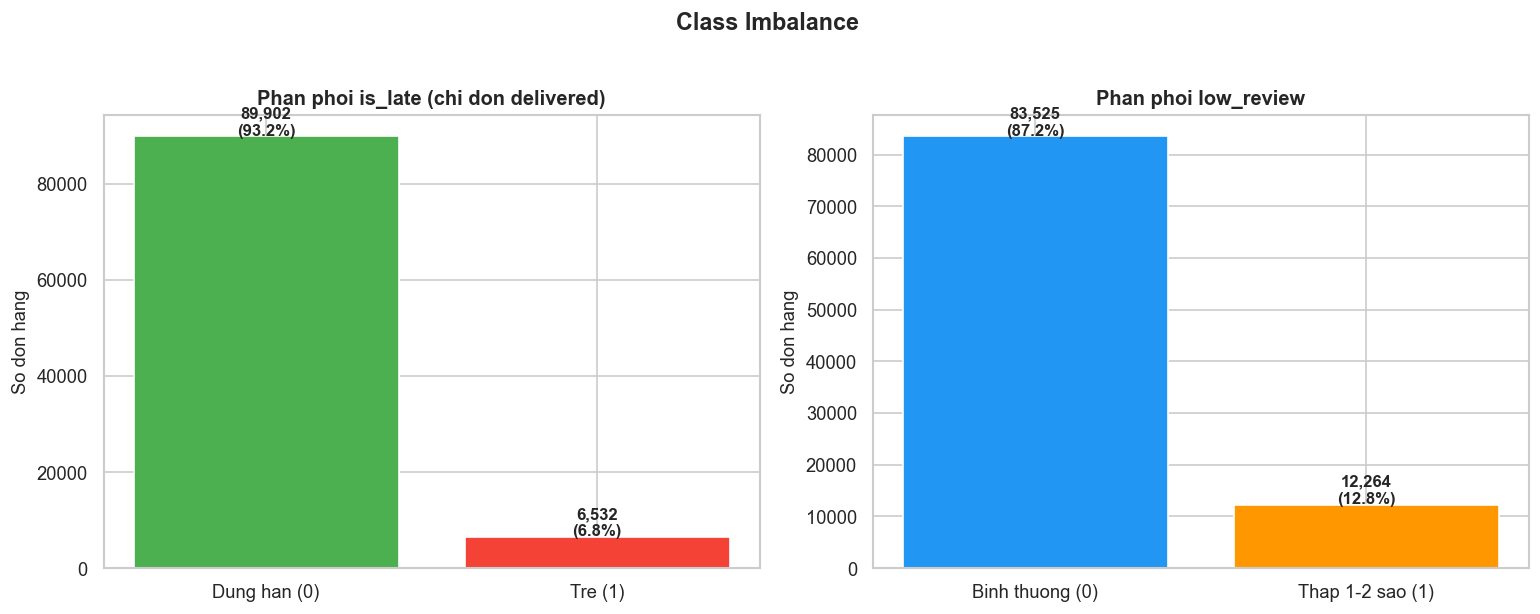

is_late   : 89,902 vs 6,532 => ratio ~1:14
low_review: 83,525 vs 12,264 => ratio ~1:7


In [14]:
# Phân phối biến mục tiêu: is_late & low_review
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- is_late ---
df_late = df_clean[df_clean['is_late'].notna()]
late_counts = df_late['is_late'].value_counts().sort_index()
colors_late = ['#4CAF50', '#F44336']
bars1 = axes[0].bar(['Dung han (0)', 'Tre (1)'], late_counts.values, color=colors_late, edgecolor='white')
for bar, v in zip(bars1, late_counts.values):
    pct = v / late_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 200,
                 f'{v:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Phan phoi is_late (chi don delivered)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('So don hang')

# --- low_review ---
df_rev = df_clean[df_clean['low_review'].notna()]
lr_counts = df_rev['low_review'].value_counts().sort_index()
colors_lr = ['#2196F3', '#FF9800']
bars2 = axes[1].bar(['Binh thuong (0)', 'Thap 1-2 sao (1)'], lr_counts.values, color=colors_lr, edgecolor='white')
for bar, v in zip(bars2, lr_counts.values):
    pct = v / lr_counts.sum() * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 200,
                 f'{v:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Phan phoi low_review', fontweight='bold', fontsize=12)
axes[1].set_ylabel('So don hang')

plt.suptitle('Class Imbalance ', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('outputs/eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# In ratio
ratio_late = late_counts.values[0] / late_counts.values[1] if len(late_counts) > 1 else 0
ratio_lr = lr_counts.values[0] / lr_counts.values[1] if len(lr_counts) > 1 else 0
print(f'is_late   : {late_counts.values[0]:,} vs {late_counts.values[1]:,} => ratio ~1:{ratio_late:.0f}')
print(f'low_review: {lr_counts.values[0]:,} vs {lr_counts.values[1]:,} => ratio ~1:{ratio_lr:.0f}')


**Nhận xét — Phân phối các biến mục tiêu**

| Biến mục tiêu (Target) | Lớp đa số (Class 0) | Lớp thiểu số (Class 1) | Tỷ lệ Imbalance | Phương án xử lý |
|---|---|---|---|---|
| **`is_late`** (Đơn trễ hạn) | **89,902** đơn đúng/sớm hạn (93.2%) | **6,532** đơn bị giao trễ (6.8%) | **~1:14** | Sử dụng `class_weight='balanced'` + Đánh giá bằng F1-Score & PR-AUC |
| **`low_review`** (Review 1-2 sao) | **83,525** đơn bình thường/tốt (87.2%) | **12,264** đơn đánh giá thấp (12.8%) | **~1:7** | Áp dụng SMOTE trên tập Train + Đánh giá bằng F1-Score & PR-AUC |


 **1. Phân tích góc độ Nghiệp vụ (Business Impact)**
* **Tác động của giao hàng trễ (`is_late`):** Mặc dù chỉ chiếm 6.8% tổng số đơn hàng, con số 6,532 đơn trễ tương đương với hàng ngàn khách hàng phải chịu trải nghiệm không tốt mỗi tháng. Giao hàng trễ là nguyên nhân cốt lõi dẫn đến các khiếu nại logistics và trực tiếp làm tăng chi phí vận hành cho bộ phận CSKH của Olist.
* **Tác động của đánh giá thấp (`low_review`):** Tỷ lệ review thấp chiếm 12.8% cao gần gấp đôi tỷ lệ giao hàng trễ (6.8%). Điều này cho thấy bên cạnh nguyên nhân do giao hàng trễ, khách hàng đánh giá 1-2 sao còn vì các lý do khác như: chất lượng sản phẩm kém, seller đóng gói sai sản phẩm, hoặc mô tả sản phẩm không đúng thực tế. Việc dự đoán sớm các đơn hàng có nguy cơ review thấp giúp sàn Olist và các seller chủ động can thiệp như tặng voucher, gọi điện xin lỗi trước khi đánh giá được công khai trên hệ thống.



**2. Ảnh hưởng đến Huấn luyện Mô hình**
* **Bẫy độ chính xác:** Do sự mất cân bằng lớp nghiêm trọng đặc biệt là `is_late` với tỷ lệ 1:14, nếu ta sử dụng một mô hình Baseline có thể luôn dự đoán tất cả đơn hàng là đúng hạn (Class 0), mô hình vẫn đạt độ chính xác **Accuracy lên đến 93.2%**. Tuy nhiên, mô hình này hoàn toàn vô dụng vì không phát hiện được bất kỳ đơn hàng rủi ro nào. Do đó, **Accuracy không được dùng làm metric chính** để đánh giá mô hình.
* **Metric thay thế tối ưu:**
  * **Recall:** Cần tối đa hóa để không bỏ sót các đơn hàng có nguy cơ cao (đặc biệt quan trọng với bài toán CSKH và Logistics).
  * **Precision:** Cần giữ ở mức hợp lý để tránh việc gửi cảnh báo giả quá nhiều gây phiền phức cho khách hàng hoặc làm quá tải nhân viên CSKH.
  * **F1-Score & PR-AUC:** Chỉ số trung bình điều hòa F1 và diện tích dưới đường cong Precision-Recall (PR-AUC) sẽ là thước đo chính để chọn ra mô hình tối ưu.
* **Chiến thuật xử lý mất cân bằng lớp:**
  * **Bài toán 1 (`is_late`):** Sử dụng các mô hình hỗ trợ gán trọng số lớp phạt lỗi sai của lớp thiểu số nặng hơn (ví dụ: `class_weight='balanced'` trong Random Forest / Logistic Regression, hoặc chỉnh tham số `scale_pos_weight` trong XGBoost).
  * **Bài toán 2 (`low_review`):** Sử dụng kỹ thuật **SMOTE**  để sinh thêm dữ liệu giả lập cho lớp 1 trên tập huấn luyện (Train set), giúp mô hình học được các đặc trưng của nhóm khách hàng không hài lòng một cách tốt hơn mà không bị bias sang lớp đa số.


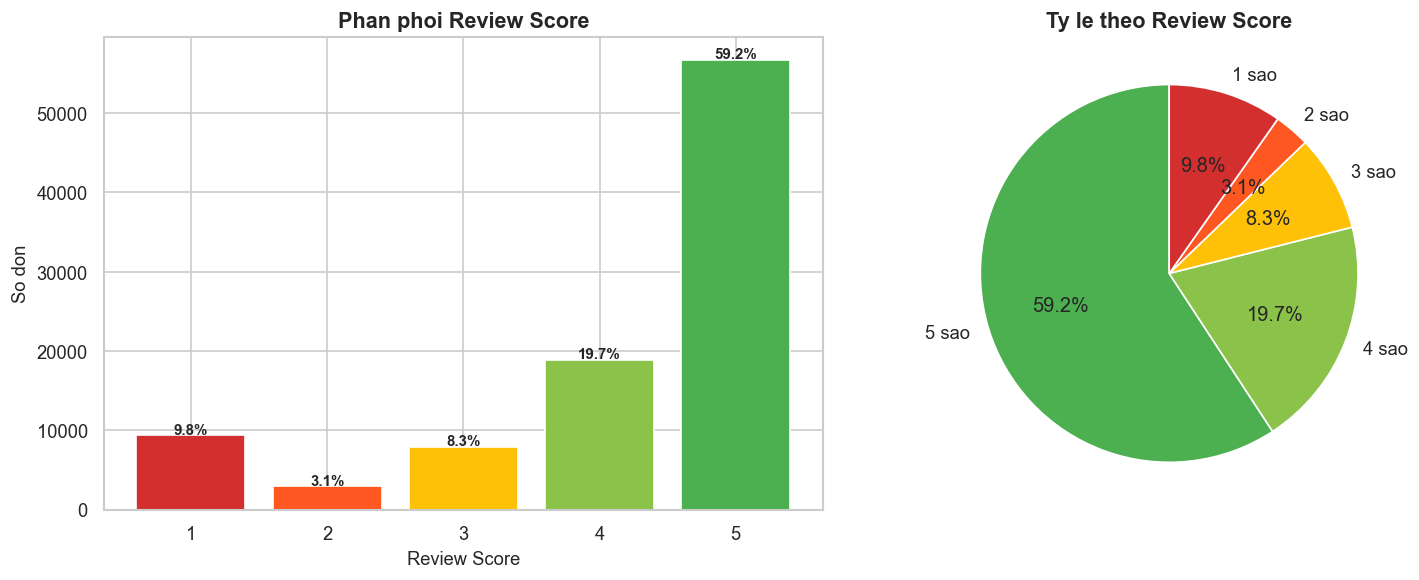

In [15]:

# Phan phoi Review Score
df_eda = df_clean[df_clean['review_score'] != -1].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count plot
score_counts = df_eda['review_score'].value_counts().sort_index()
colors_score = ['#D32F2F','#FF5722','#FFC107','#8BC34A','#4CAF50']
bars = axes[0].bar(score_counts.index, score_counts.values, color=colors_score, edgecolor='white')
for bar, v in zip(bars, score_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 200,
                 f'{v/len(df_eda)*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('So don')
axes[0].set_title('Phan phoi Review Score', fontweight='bold')

# Pie chart
labels_pie = ['5 sao', '4 sao', '3 sao', '2 sao', '1 sao']
sizes = score_counts.reindex([5,4,3,2,1]).values
axes[1].pie(sizes, labels=labels_pie, autopct='%1.1f%%',
            colors=colors_score[::-1], startangle=90)
axes[1].set_title('Ty le theo Review Score', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/eda_review_score.png', dpi=150, bbox_inches='tight')
plt.show()




**Phân tích số liệu từ biểu đồ**
* **Đánh giá tích cực chiếm ưu thế:** Đơn hàng được chấm **5 sao chiếm tỷ lệ lớn nhất (59.2%)**, theo sau là **4 sao (19.7%)**. Tổng cộng, nhóm đánh giá tốt (4–5 sao) chiếm **78.9%** tổng số đơn hàng. Điều này cho thấy phần lớn khách hàng của Olist hài lòng với trải nghiệm mua sắm.
* **Tỷ lệ đánh giá thấp (vùng rủi ro):** Nhóm đánh giá tiêu cực (1–2 sao) chiếm tổng cộng **12.9%** (gần 13%). Đây chính là biến mục tiêu `low_review = 1` cần được dự báo và xử lý.
* **Hiện tượng cực đoan ở nhóm tiêu cực:** Đáng chú ý là **tỷ lệ đơn hàng bị đánh giá 1 sao (9.8%) cao gấp hơn 3 lần so với 2 sao (3.1%)**. Điều này chứng tỏ khi khách hàng không hài lòng (do giao hàng trễ, sai sản phẩm, hư hỏng...), họ có xu hướng đánh giá cực kỳ khắt khe (1 sao) thay vì trung bình-thấp (2 sao).



**Business Insights**
* **Thiệt hại của Review xấu:** Đối với các sàn TMĐT như Olist, 1 review tiêu cực đặc biệt là 1 sao sẽ trực tiếp kéo tụt điểm rating của sản phẩm và độ uy tín của Seller, làm giảm nghiêm trọng tỷ lệ chuyển đổi và doanh thu của gian hàng.
* **Cơ hội cải thiện dịch vụ:** Với khoảng 13% đơn hàng bị đánh giá thấp, Olist cần có cơ chế cảnh báo sớm. Nếu hệ thống dự đoán trước một đơn hàng có nguy cơ nhận 1-2 sao (ví dụ: do vận chuyển bị tắc nghẽn), bộ phận CSKH có thể chủ động liên hệ xin lỗi, tặng voucher hoặc xử lý bồi thường trước khi khách hàng viết đánh giá tiêu cực công khai.


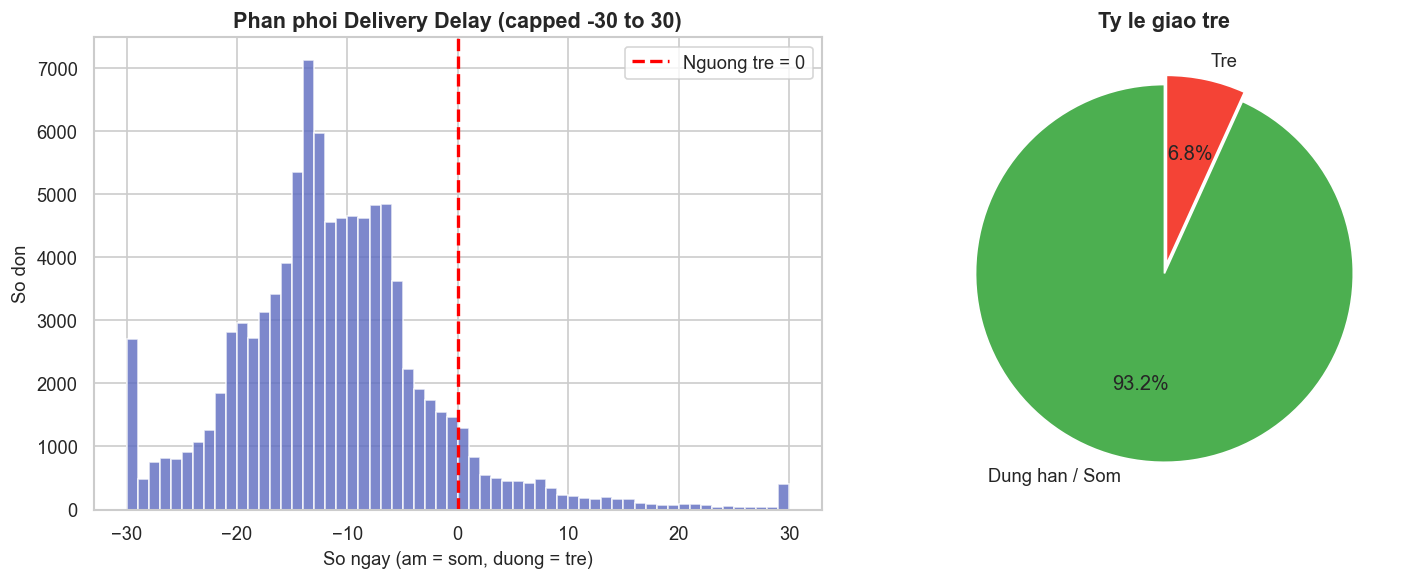

Thong ke delay:
count   96434.00
mean      -11.86
std        10.06
min       -60.00
25%       -17.00
50%       -12.00
75%        -7.00
max       175.00
Name: delivery_delay_days, dtype: float64


In [16]:
# Phan phoi Delivery Delay
df_delivered = df_clean[
    (df_clean['order_status'] == 'delivered') &
    (df_clean['delivery_delay_days'].notna())
].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
df_delivered['delay_capped'] = df_delivered['delivery_delay_days'].clip(-30, 30)
axes[0].hist(df_delivered['delay_capped'], bins=60, color='#5C6BC0', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Nguong tre = 0')
axes[0].set_xlabel('So ngay (am = som, duong = tre)')
axes[0].set_ylabel('So don')
axes[0].set_title('Phan phoi Delivery Delay (capped -30 to 30)', fontweight='bold')
axes[0].legend()

# Pie: late vs on-time
late_pct = df_delivered['is_late'].mean() * 100
axes[1].pie([100 - late_pct, late_pct],
            labels=['Dung han / Som', 'Tre'],
            colors=['#4CAF50', '#F44336'],
            autopct='%1.1f%%', startangle=90,
            explode=[0, 0.05])
axes[1].set_title('Ty le giao tre', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/eda_delivery_delay.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Thong ke delay:')
print(df_delivered['delivery_delay_days'].describe())


**Phân tích số liệu từ biểu đồ**

- **Đại đa số đơn hàng giao sớm hoặc đúng hạn:** **93.2%** đơn hàng được giao đúng hạn hoặc sớm hơn dự kiến. Biểu đồ phân phối histogram lệch mạnh về phía âm (bên trái đường nét đứt màu đỏ `Nguong tre = 0`).
- **Khoảng đệm thời gian (Buffer) lớn:** Đỉnh của phân phối nằm ở mức **-13 đến -14 ngày**. Điều này có nghĩa là phần lớn đơn hàng được giao đến tay khách hàng sớm hơn ngày dự kiến giao ước tính tới gần 2 tuần.
- **Tỷ lệ giao trễ thấp:** Chỉ có **6.8%** đơn hàng thực sự bị giao trễ so với ngày dự kiến giao cam kết trên hệ thống.

**Business Insights**

- **Logistics hoạt động ổn định nhưng tính toán thời gian dự kiến chưa tối ưu:** Việc phần lớn đơn hàng giao sớm trung bình tới 13 ngày cho thấy Olist đang đặt thời gian dự kiến giao hàng quá dài. Điều này có thể khiến khách hàng ngần ngại mua hàng ngay từ bước thanh toán vì thấy thời gian chờ đợi quá lâu. Olist nên tối ưu hóa thuật toán ước tính thời gian giao hàng để đưa ra ngày dự kiến sát thực tế hơn.
- **Tác động tiêu cực của 6.8% giao trễ:** Tuy tỷ lệ giao trễ chỉ 6.8%, nhưng đối với TMĐT, giao trễ là lý do hàng đầu dẫn đến sự thất vọng của khách hàng. Giao trễ là nguyên nhân cốt lõi đóng góp trực tiếp vào tỷ lệ đánh giá thấp 1-2 sao của khách hàng trên hệ thống.

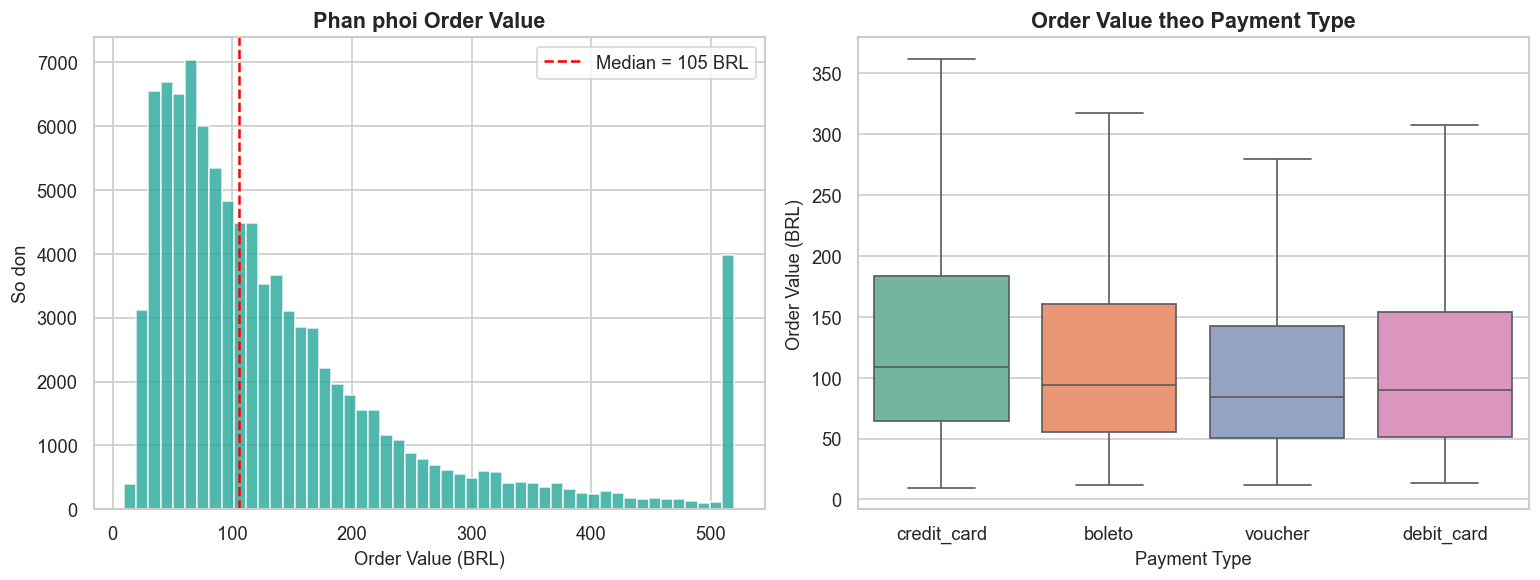

In [17]:
# Phan phoi Order Value
df_val = df_clean[df_clean['order_value'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(df_val['order_value'], bins=50, color='#26A69A', edgecolor='white', alpha=0.8)
axes[0].axvline(x=df_val['order_value'].median(), color='red', linestyle='--',
                label=f'Median = {df_val["order_value"].median():.0f} BRL')
axes[0].set_xlabel('Order Value (BRL)')
axes[0].set_ylabel('So don')
axes[0].set_title('Phan phoi Order Value', fontweight='bold')
axes[0].legend()

# Boxplot by payment_type
top_payments = df_val['payment_type'].value_counts().head(4).index
df_pay = df_val[df_val['payment_type'].isin(top_payments)]
sns.boxplot(data=df_pay, x='payment_type', y='order_value', ax=axes[1],
            palette='Set2', showfliers=False)
axes[1].set_title('Order Value theo Payment Type', fontweight='bold')
axes[1].set_xlabel('Payment Type')
axes[1].set_ylabel('Order Value (BRL)')

plt.tight_layout()
plt.savefig('outputs/eda_order_value.png', dpi=150, bbox_inches='tight')
plt.show()


**Phân tích số liệu từ biểu đồ**

- **Phân phối lệch phải mạnh:** Hầu hết các đơn hàng có giá trị thấp đến trung bình, tập trung chủ yếu trong khoảng từ 30 đến 200 BRL. Giá trị trung vị của đơn hàng là **105 BRL**, cho thấy các giao dịch nhỏ lẻ chiếm ưu thế lớn trong mô hình bán lẻ của Olist.
- **Sự khác biệt giữa các phương thức thanh toán:** 
  - **Credit card:** Có mức giá trị đơn hàng trung vị cao nhất khoảng 110 BRL và dải phân bổ rộng nhất. Khách hàng có xu hướng sử dụng thẻ tín dụng cho các giao dịch lớn hơn.
  - **Boleto và Debit card:** Có giá trị trung vị thấp hơn, lần lượt khoảng 95 BRL và 90 BRL, thường dùng cho các đơn hàng giá trị trung bình và nhỏ.
  - **Voucher:** Có giá trị trung vị thấp nhất khoảng 85 BRL, phản ánh hành vi sử dụng voucher để giảm trừ một phần hóa đơn hoặc mua các sản phẩm giá trị nhỏ.

**Business Insights**

- **Đặc trưng chi tiêu của thị trường Brazil:** Mức chi tiêu trung vị 105 BRL cho thấy các mặt hàng phổ thông chiếm đa số doanh số. Olist cần tập trung tối ưu hóa trải nghiệm thanh toán nhanh cho phân khúc này.
- **Thúc đẩy tăng giá trị đơn hàng:** Khách hàng sử dụng thẻ tín dụng sẵn sàng chi tiêu nhiều hơn. Olist có thể áp dụng các chính sách như miễn phí vận chuyển cho đơn hàng trên một ngưỡng nhất định, hoặc liên kết với ngân hàng để ưu đãi trả góp qua thẻ tín dụng nhằm kích thích khách hàng mua nhiều hơn trong một lần giao dịch.

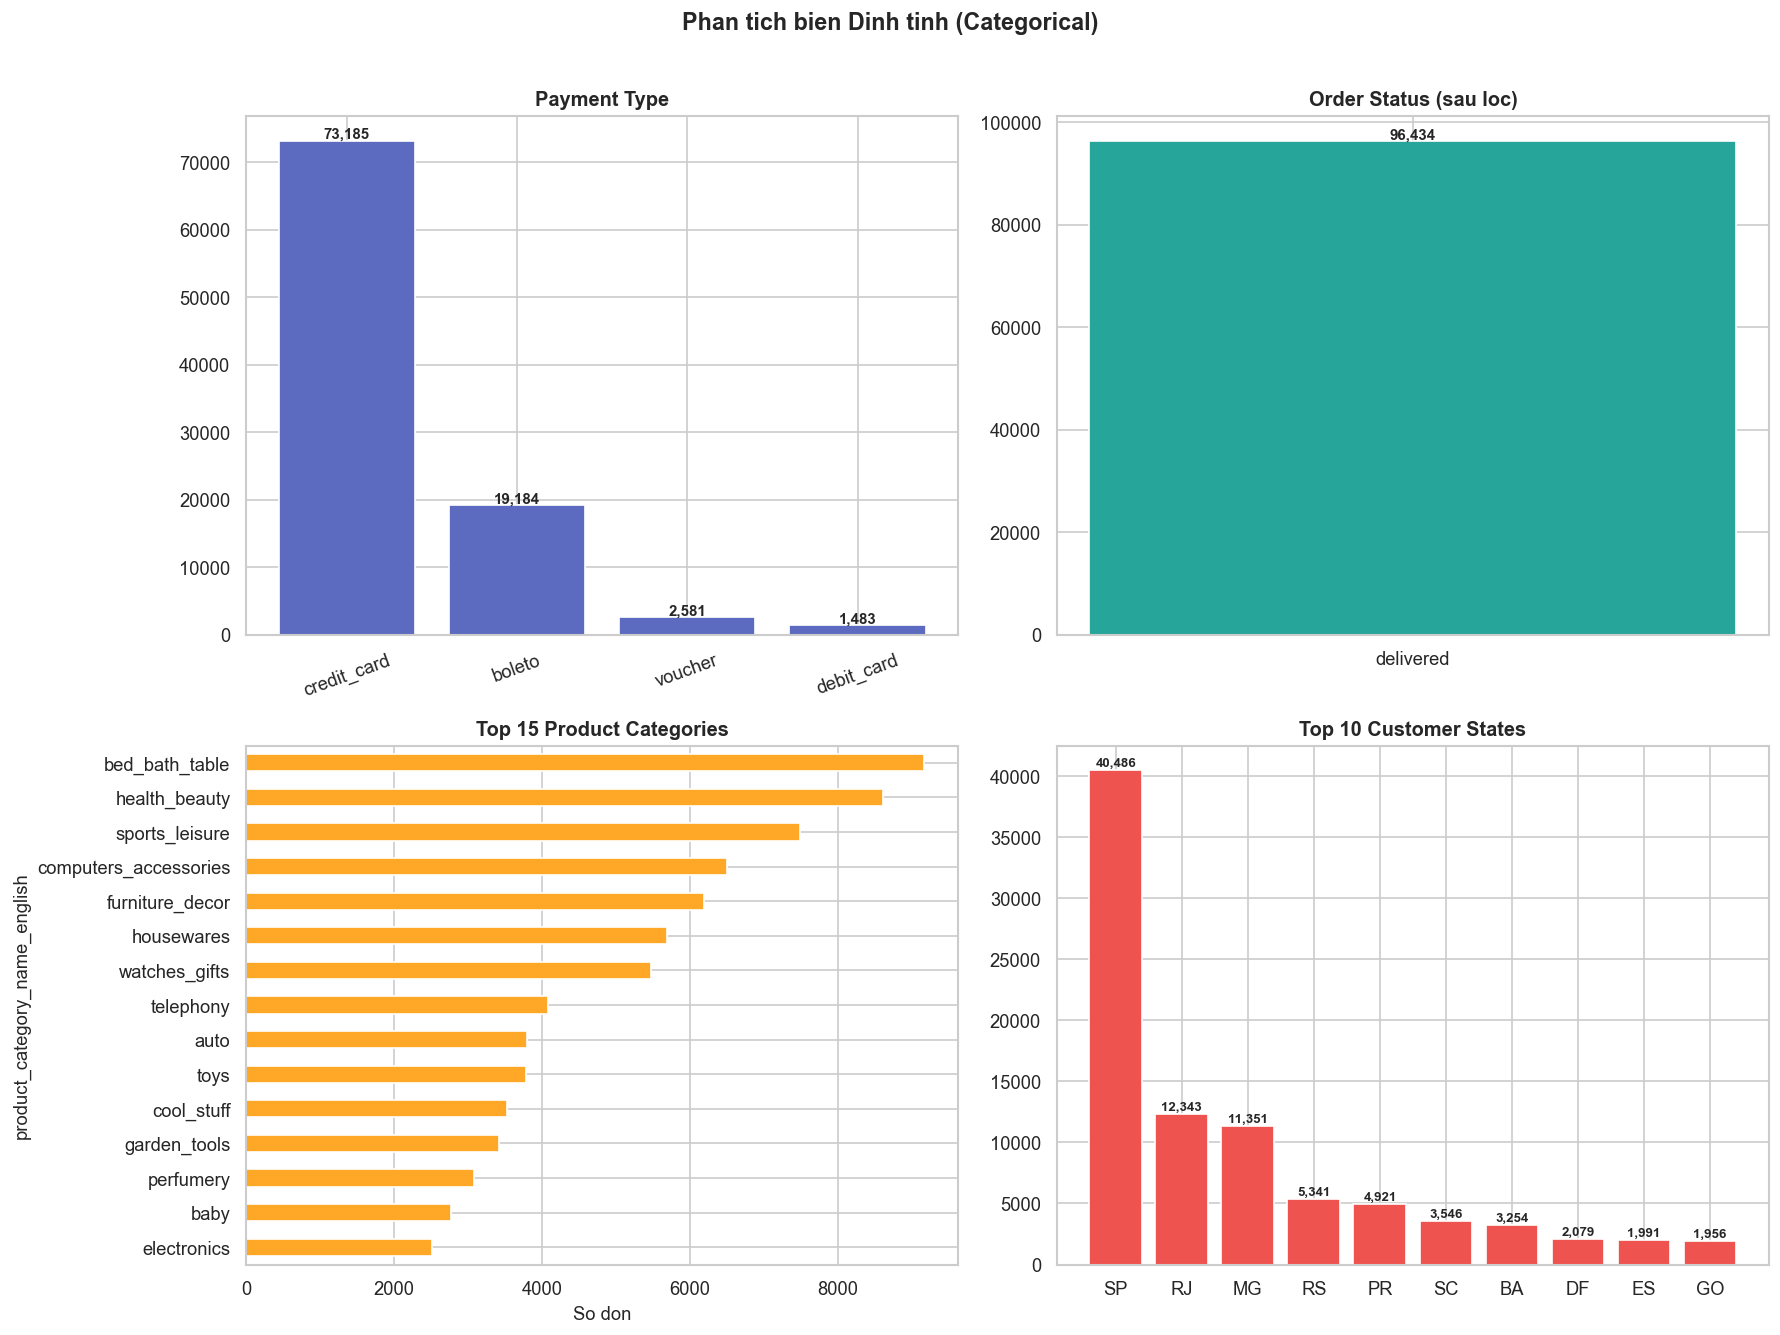

In [18]:
#  Phan tich bien dinh tinh (Categorical)
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

#  Payment Type
pay_counts = df_clean['payment_type'].value_counts()
axes[0,0].bar(pay_counts.index, pay_counts.values, color='#5C6BC0', edgecolor='white')
for i, v in enumerate(pay_counts.values):
    axes[0,0].text(i, v + 300, f'{v:,}', ha='center', fontsize=9, fontweight='bold')
axes[0,0].set_title('Payment Type', fontweight='bold', fontsize=12)
axes[0,0].tick_params(axis='x', rotation=20)

#  Order Status
status_counts = df_clean['order_status'].value_counts()
axes[0,1].bar(status_counts.index, status_counts.values, color='#26A69A', edgecolor='white')
for i, v in enumerate(status_counts.values):
    axes[0,1].text(i, v + 300, f'{v:,}', ha='center', fontsize=9, fontweight='bold')
axes[0,1].set_title('Order Status (sau loc)', fontweight='bold', fontsize=12)

#  Top 15 Product Category
cat_counts = df_clean['product_category_name_english'].value_counts().head(15)
cat_counts.plot.barh(ax=axes[1,0], color='#FFA726', edgecolor='white')
axes[1,0].set_title('Top 15 Product Categories', fontweight='bold', fontsize=12)
axes[1,0].set_xlabel('So don')
axes[1,0].invert_yaxis()

#  Top 10 Customer State
state_counts = df_clean['customer_state'].value_counts().head(10)
axes[1,1].bar(state_counts.index, state_counts.values, color='#EF5350', edgecolor='white')
for i, v in enumerate(state_counts.values):
    axes[1,1].text(i, v + 300, f'{v:,}', ha='center', fontsize=8, fontweight='bold')
axes[1,1].set_title('Top 10 Customer States', fontweight='bold', fontsize=12)

plt.suptitle('Phan tich bien Dinh tinh (Categorical)', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs/eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()


**Phân tích số liệu từ biểu đồ**

- **Phương thức thanh toán phổ biến:** Credit card là phương thức thanh toán được lựa chọn nhiều nhất với hơn 73 nghìn đơn hàng. Boleto đứng vị trí thứ hai với hơn 19 nghìn đơn hàng, trong khi voucher và debit card chiếm tỷ lệ rất nhỏ.
- **Trạng thái đơn hàng sau khi lọc:** Hầu như toàn bộ dữ liệu phân tích chỉ tập trung vào trạng thái delivered với hơn 96 nghìn đơn hàng, cho thấy dữ liệu đã được làm sạch để phân tích hành vi giao hàng thực tế.
- **Ngành hàng dẫn đầu:** Bed bath table, health beauty và sports leisure là ba danh mục sản phẩm có số lượng đơn hàng lớn nhất, vượt trội hơn hẳn so với các danh mục còn lại.
- **Phân bổ địa lý của khách hàng:** Bang São Paulo chiếm thị phần áp đảo với hơn 40 nghìn đơn hàng, lớn hơn tổng số đơn hàng của tất cả các bang khác trong top 10 cộng lại. Rio de Janeiro và Minas Gerais lần lượt đứng tiếp theo với số lượng đơn hàng tương đương nhau.

**Business Insights**

- **Chiến lược tối ưu hóa thanh toán:** Olist nên tập trung cải thiện trải nghiệm thanh toán bằng thẻ tín dụng thông qua các tính năng như lưu thông tin thẻ bảo mật. Bên cạnh đó, việc chấp nhận Boleto là cần thiết vì phương thức này vẫn chiếm một lượng khách hàng đáng kể tại thị trường Brazil.
- **Tập trung nguồn lực kho bãi và vận chuyển:** São Paulo là thị trường trọng điểm tuyệt đối. Olist nên xây dựng các trung tâm hoàn thiện đơn hàng gần khu vực này để tối ưu hóa thời gian vận chuyển. Đối với các bang xa hơn như Rio de Janeiro hay Minas Gerais, cần có các đối tác giao nhận phụ trợ để duy trì thời gian giao hàng ổn định.
- **Chiến dịch tiếp thị theo ngành hàng:** Các nhóm hàng gia dụng và chăm sóc sức khỏe sắc đẹp có nhu cầu rất cao. Olist có thể triển khai các chiến dịch khuyến mãi chéo, gợi ý mua kèm giữa các sản phẩm thuộc ba danh mục dẫn đầu này để tối đa hóa doanh số bán hàng.


## 5.2 Phân tích xu hướng theo thời gian 


- Phân tích xu hướng doanh thu và số đơn theo tháng 
- Xác định mùa vụ, đỉnh điểm (Black Friday 11/2017)
- Phân tích giờ mua hàng trong ngày và trong tuần 





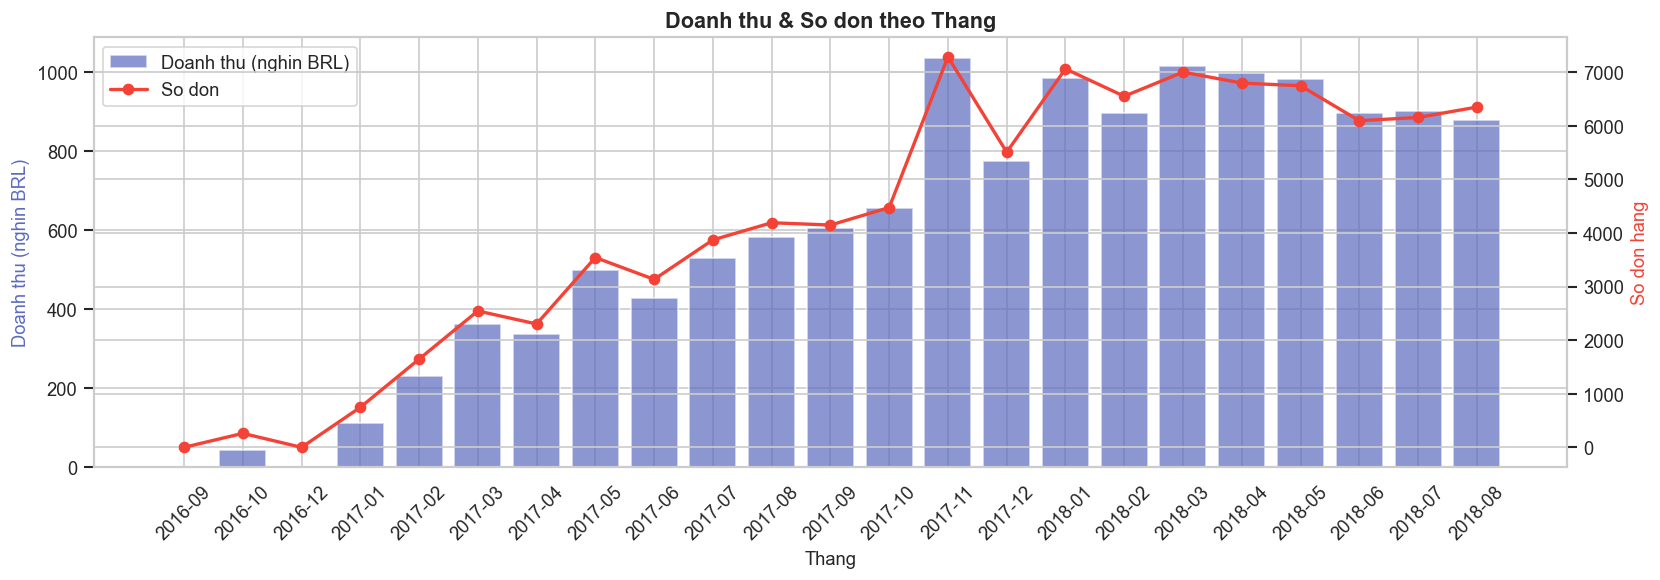

In [19]:
# Doanh thu & So don theo Thang
monthly = df_clean.groupby('purchase_year_month').agg(
    revenue=('order_value', 'sum'),
    n_orders=('order_id', 'nunique')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['purchase_year_month'], monthly['revenue']/1000,
        color='#5C6BC0', alpha=0.7, label='Doanh thu (nghin BRL)')
ax2.plot(monthly['purchase_year_month'], monthly['n_orders'],
         color='#F44336', marker='o', linewidth=2, label='So don')

ax1.set_xlabel('Thang')
ax1.set_ylabel('Doanh thu (nghin BRL)', color='#5C6BC0')
ax2.set_ylabel('So don hang', color='#F44336')
ax1.set_title('Doanh thu & So don theo Thang', fontweight='bold', fontsize=13)
ax1.tick_params(axis='x', rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('outputs/eda_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()


**Phân tích số liệu từ biểu đồ**

- **Giai đoạn khởi đầu thử nghiệm:** Từ tháng 9 năm 2016 đến tháng 12 năm 2016, số lượng đơn hàng và doanh thu ở mức cực kỳ thấp, gần như bằng không. Đây là thời kỳ đầu khi nền tảng Olist bắt đầu đi vào hoạt động thử nghiệm.
- **Tăng trưởng liên tục trong năm 2017:** Bắt đầu từ tháng 1 năm 2017, số đơn hàng và doanh thu đều tăng trưởng đều đặn qua từng tháng. Doanh thu tăng từ mức khoảng 100 nghìn BRL vào tháng 1 lên mức hơn 600 nghìn BRL vào tháng 10 năm 2017.
- **Đỉnh điểm vượt trội vào tháng 11 năm 2017:** Số lượng đơn hàng đạt mốc cao nhất với hơn 7000 đơn và doanh thu vượt mốc 1 triệu BRL. Sự gia tăng đột biến này tương ứng với đợt mua sắm lớn Black Friday.
- **Duy trì quy mô ổn định trong năm 2018:** Sau khi sụt giảm vào tháng 12 năm 2017 xuống còn khoảng 770 nghìn BRL, hoạt động kinh doanh nhanh chóng phục hồi và duy trì sự ổn định trong suốt tám tháng đầu năm 2018. Doanh thu luôn giữ vững ở mức cao dao động xung quanh 900 nghìn BRL mỗi tháng với khoảng 6000 đến 7000 đơn hàng.

**Business Insights**

- **Dự báo nhu cầu và tối ưu chi phí vận hành cuối năm:** Sự sụt giảm doanh số ngay sau tháng 11 cho thấy nhu cầu mua sắm bị bão hòa nhanh sau đợt siêu khuyến mãi. Doanh nghiệp cần chủ động điều chỉnh quy mô nhân sự vận chuyển giảm dần vào tháng 12 để tránh dư thừa và tối ưu hóa chi phí.
- **Duy trì tệp khách hàng sau sự kiện lớn:** Giai đoạn từ tháng 1 đến tháng 5 năm 2018 chứng kiến sự phục hồi và giữ nhịp rất tốt. Điều này chứng tỏ các chương trình giữ chân khách hàng cũ và khai thác khách hàng mới sau đợt Black Friday đã phát huy tác dụng. Olist cần tiếp tục thiết kế các chương trình ưu đãi cá nhân hóa để duy trì sự gắn bó của tệp khách hàng này.
- **Thúc đẩy tăng trưởng khi thị trường đi ngang:** Từ giữa năm 2018, số lượng đơn hàng có xu hướng đi ngang ở mức cao. Để tiếp tục tăng trưởng và phá vỡ ngưỡng này, Olist cần mở rộng thêm các danh mục sản phẩm mới hoặc thu hút thêm các nhà bán hàng lớn để tăng tính đa dạng cho sàn thương mại điện tử.

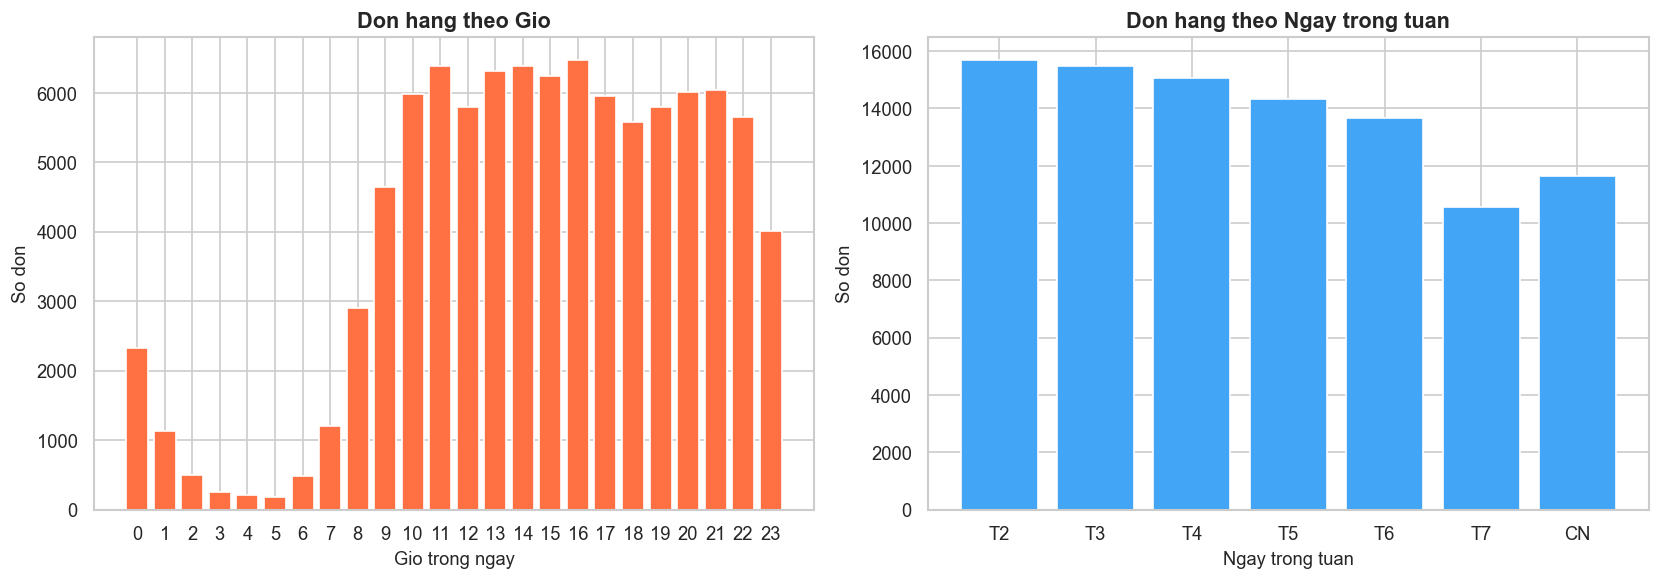

In [20]:
# ============================================================
# 9.2 Hanh vi mua theo Gio & Ngay trong tuan
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Theo gio
hourly = df_clean.groupby('purchase_hour')['order_id'].count()
axes[0].bar(hourly.index, hourly.values, color='#FF7043', edgecolor='white')
axes[0].set_xlabel('Gio trong ngay')
axes[0].set_ylabel('So don')
axes[0].set_title('Don hang theo Gio', fontweight='bold')
axes[0].set_xticks(range(0, 24))

# Theo ngay
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df_clean.groupby('purchase_dow')['order_id'].count().reindex(dow_order)
axes[1].bar(range(7), daily.values, color='#42A5F5', edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['T2','T3','T4','T5','T6','T7','CN'])
axes[1].set_xlabel('Ngay trong tuan')
axes[1].set_ylabel('So don')
axes[1].set_title('Don hang theo Ngay trong tuan', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/eda_time_pattern.png', dpi=150, bbox_inches='tight')
plt.show()


**Phân tích số liệu từ biểu đồ**

- **Hành vi mua sắm tập trung vào ban ngày:** Lượng đơn hàng phân bổ nhiều nhất vào khung giờ làm việc và buổi tối, kéo dài từ 9 giờ sáng đến 22 giờ đêm. Các đỉnh đặt hàng nhỏ xuất hiện vào lúc 11 giờ trưa, 14 giờ chiều, 16 giờ chiều và 21 giờ tối với hơn 6000 đơn hàng cho mỗi khung giờ.
- **Thời gian thấp điểm mua sắm:** Số lượng đơn hàng sụt giảm nghiêm trọng từ sau nửa đêm và chạm đáy vào khoảng từ 3 giờ đến 5 giờ sáng với chưa đầy 300 đơn hàng mỗi giờ. Lượng đơn bắt đầu phục hồi dần từ 7 giờ sáng.
- **Hoạt động mua sắm sôi nổi vào đầu tuần:** Khách hàng đặt mua nhiều nhất vào thứ hai và thứ ba với gần 16 nghìn đơn hàng mỗi ngày. Lượng đặt hàng giảm dần theo các ngày tiếp theo trong tuần.
- **Sự sụt giảm vào ngày nghỉ cuối tuần:** Thứ bảy ghi nhận lượng đơn hàng thấp nhất tuần với khoảng 10500 đơn hàng. Lượng đơn hàng tăng nhẹ trở lại vào chủ nhật nhưng vẫn ở mức thấp hơn so với các ngày làm việc trong tuần.

**Business Insights**

- **Tối ưu hóa thời gian chạy quảng cáo và khuyến mãi:** Các chiến dịch quảng cáo trực tiếp và thông báo đẩy khuyến mãi nên tập trung vào các khung giờ vàng từ 10 giờ sáng đến 16 giờ chiều và khung giờ tối từ 20 giờ đến 21 giờ đêm. Điều này giúp tối ưu hóa chi phí hiển thị và tăng tỷ lệ đặt hàng thành công.
- **Chiến lược gửi thông điệp tiếp thị theo tuần:** Việc gửi các email tiếp thị, giới thiệu sản phẩm mới hoặc mã giảm giá nên được ưu tiên thực hiện vào sáng thứ hai hoặc thứ ba để đón đầu làn sóng mua sắm mạnh nhất của khách hàng trong tuần.
- **Tạo chương trình kích cầu cuối tuần:** Nhằm cải thiện lượng đơn hàng sụt giảm vào thứ bảy và chủ nhật, Olist có thể tổ chức các sự kiện khuyến mại ngắn hạn dành riêng cho cuối tuần. Ví dụ như chương trình săn mã giảm giá cuối tuần hoặc hỗ trợ phí vận chuyển vào thứ bảy và chủ nhật để kích thích nhu cầu mua sắm của nhóm khách hàng rảnh rỗi vào ngày nghỉ.


## 5.3 Phân tích theo địa lý và danh mục sản phẩm       

 
- Xác định bang tập trung nhiều khách nhất 
- Phân tích tỷ lệ giao trễ theo seller state
- So sánh top categories theo doanh thu va số đơn




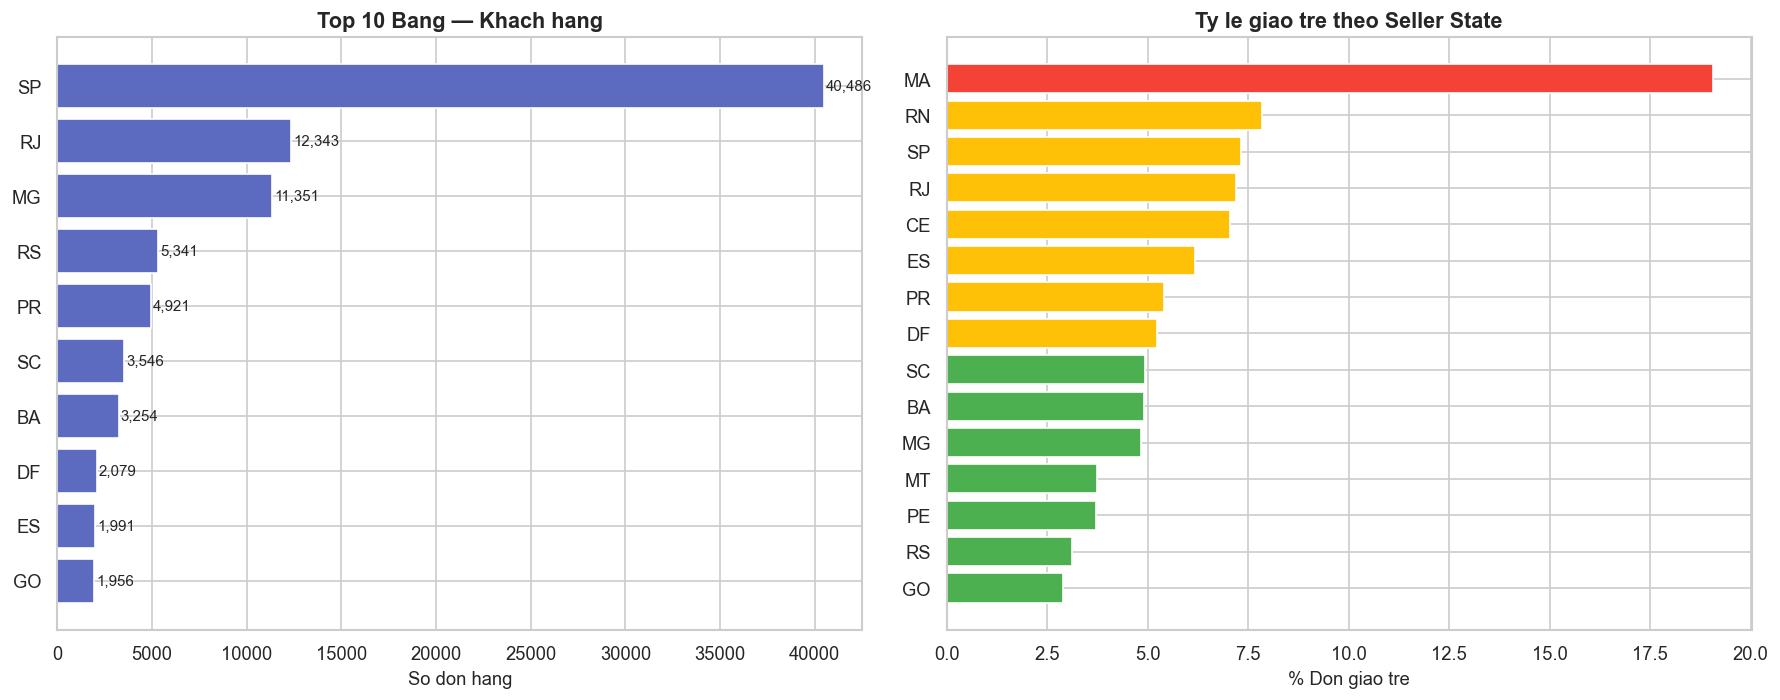

In [21]:

# Phân bố khách hàng theo Bang + Late rate theo Seller State
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# KH theo bang
top_states = df_clean['customer_state'].value_counts().head(10)
axes[0].barh(top_states.index[::-1], top_states.values[::-1], color='#5C6BC0', edgecolor='white')
axes[0].set_xlabel('So don hang')
axes[0].set_title('Top 10 Bang — Khach hang', fontweight='bold')
for i, v in enumerate(top_states.values[::-1]):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# Late rate theo seller state
df_del = df_clean[df_clean['is_late'].notna()]
late_by_state = df_del.groupby('seller_state')['is_late'].agg(['mean','count'])
late_by_state = late_by_state[late_by_state['count'] >= 50].sort_values('mean', ascending=False).head(15)
colors_bar = ['#F44336' if v > 0.1 else '#FFC107' if v > 0.05 else '#4CAF50' for v in late_by_state['mean']]
axes[1].barh(late_by_state.index[::-1], late_by_state['mean'].values[::-1] * 100,
             color=colors_bar[::-1], edgecolor='white')
axes[1].set_xlabel('% Don giao tre')
axes[1].set_title('Ty le giao tre theo Seller State', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/eda_geo_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


**Phân tích số liệu từ biểu đồ**

- **Phân bổ lượng khách hàng vượt trội:** Bang São Paulo đứng đầu danh sách với 40486 đơn hàng, bỏ xa hai bang tiếp theo là Rio de Janeiro với 12343 đơn hàng và Minas Gerais với 11351 đơn hàng. Các bang khác đều có số lượng đơn hàng dưới mức 6000 đơn.
- **Tỷ lệ giao trễ nghiêm trọng ở một số khu vực:** Bang Maranhão ghi nhận tỷ lệ giao hàng trễ cao nhất và vượt trội ở mức khoảng 19 phần trăm. Đây là khu vực được biểu diễn bằng cột màu đỏ, thể hiện mức độ rủi ro chậm trễ rất cao trong vận chuyển. Do đó lượng khách hàng của bang này cũng tỷ lệ nghịch so với tỷ lệ giao trễ.
- **Tỷ lệ giao trễ ở mức trung bình:** Các bang như Rio Grande do Norte, São Paulo, Rio de Janeiro, Ceará, Espírito Santo, Paraná và Distrito Federal có tỷ lệ giao trễ nằm trong khoảng từ 5 phần trăm đến 10 phần trăm, được biểu diễn bằng các cột màu vàng.
- **Khu vực kiểm soát giao hàng tốt:** Các bang như Santa Catarina, Bahia, Minas Gerais, Mato Grosso, Pernambuco, Rio Grande do Sul và Goiás giữ được tỷ lệ giao trễ ở mức thấp dưới 5 phần trăm, biểu diễn bằng các cột màu xanh lá cây.

**Business Insights**

- **Hạn chế rủi ro vận chuyển tại khu vực có tỷ lệ trễ cao:** Với tỷ lệ giao trễ lên tới 19 phần trăm tại Maranhão, Olist cần kiểm tra lại năng lực vận hành của các đơn vị đối tác giao hàng tại khu vực này. Sàn thương mại điện tử nên tự động điều chỉnh tăng thời gian giao hàng dự kiến hiển thị cho người mua khi họ chọn sản phẩm từ các nhà bán hàng thuộc bang Maranhão để tránh gây thất vọng.
- **Tối ưu hóa logistics tại các bang trọng điểm:** Mặc dù São Paulo và Rio de Janeiro là những thị trường lớn nhất, tỷ lệ giao trễ tại đây vẫn nằm ở mức cảnh báo màu vàng với tỷ lệ hơn 7 phần trăm. Do số lượng đơn hàng ở hai khu vực này rất lớn, Olist cần thiết lập các trạm trung chuyển và tuyến vận chuyển nhanh chuyên biệt để kéo giảm tỷ lệ trễ, giúp cải thiện đáng kể trải nghiệm của phần lớn khách hàng trên sàn.
- **Khai thác lợi thế của các khu vực có logistics ổn định:** Các bang như Minas Gerais và Santa Catarina có lượng đơn hàng khá lớn nhưng kiểm soát tỷ lệ giao trễ rất tốt dưới 5 phần trăm. Olist nên có chính sách khuyến khích, ưu đãi phí sàn hoặc hỗ trợ quảng bá cho các nhà bán hàng tại các bang này để tận dụng hiệu suất giao hàng ổn định của họ.

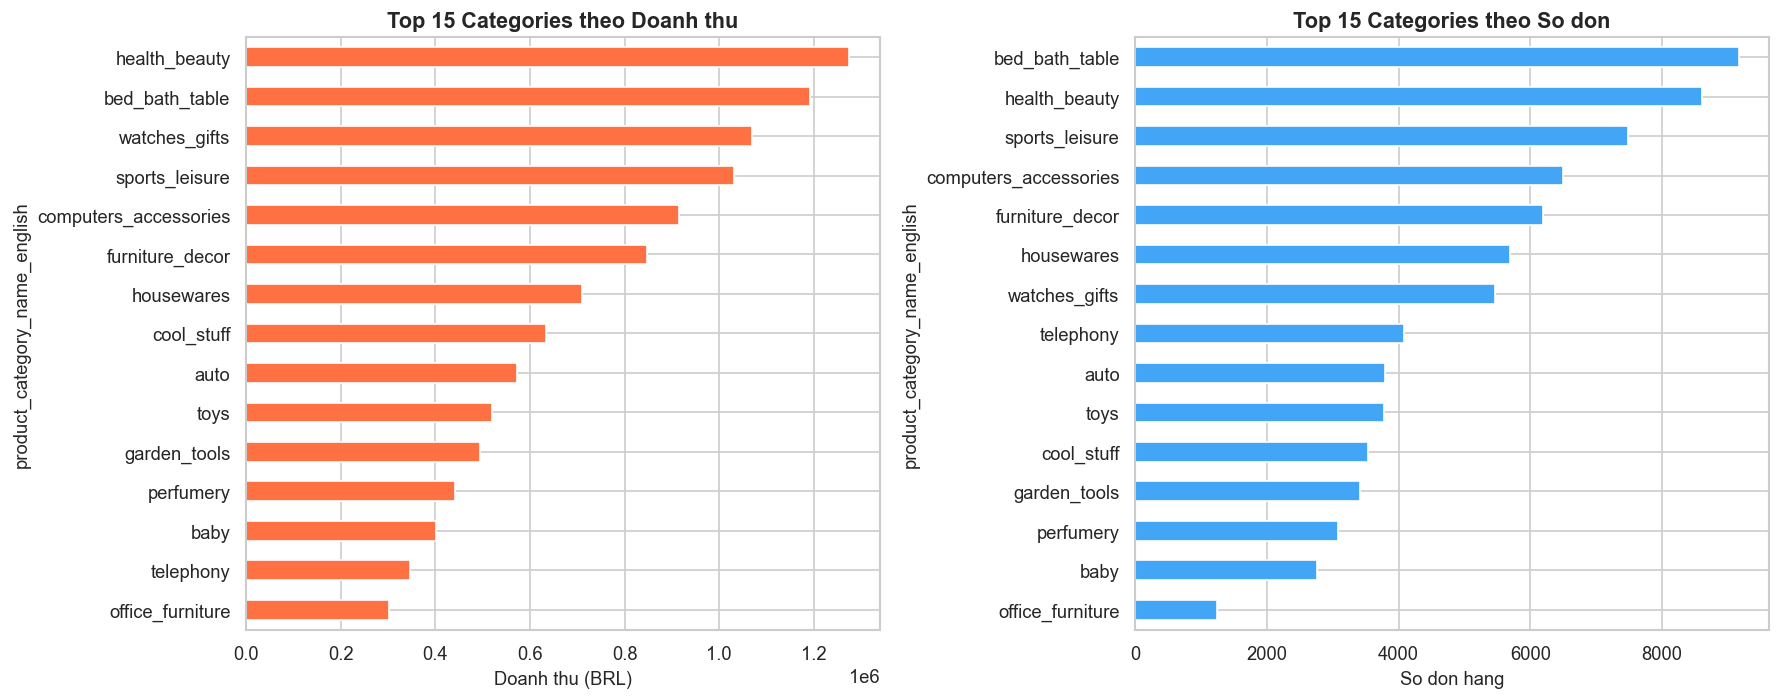

In [22]:
# Top Categories theo Doanh thu & Số đơn
cat_analysis = df_clean.groupby('product_category_name_english').agg(
    revenue=('order_value', 'sum'),
    n_orders=('order_id', 'nunique')
).sort_values('revenue', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cat_analysis['revenue'].sort_values().plot.barh(ax=axes[0], color='#FF7043', edgecolor='white')
axes[0].set_xlabel('Doanh thu (BRL)')
axes[0].set_title('Top 15 Categories theo Doanh thu', fontweight='bold')

cat_analysis['n_orders'].sort_values().plot.barh(ax=axes[1], color='#42A5F5', edgecolor='white')
axes[1].set_xlabel('So don hang')
axes[1].set_title('Top 15 Categories theo So don', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/eda_category.png', dpi=150, bbox_inches='tight')
plt.show()


**Phân tích số liệu từ biểu đồ**

- **Nhóm ngành hàng đóng góp doanh thu lớn nhất:** Ngành hàng chăm sóc sức khỏe và sắc đẹp đứng đầu về doanh thu với mức đạt khoảng 1.25 triệu BRL. Nhóm đồ dùng phòng ngủ, phòng tắm và bàn đứng thứ hai với doanh thu đạt khoảng 1.2 triệu BRL. Tiếp theo là nhóm đồng hồ và quà tặng với doanh thu khoảng 1.07 triệu BRL và nhóm đồ thể thao giải trí với khoảng 1.03 triệu BRL.
- **Nhóm ngành hàng dẫn đầu về số lượng đơn hàng:** Đồ dùng phòng ngủ, phòng tắm và bàn là danh mục có nhiều giao dịch phát sinh nhất với hơn 9200 đơn hàng. Nhóm chăm sóc sức khỏe và sắc đẹp đứng thứ hai với khoảng 8600 đơn hàng, theo sau là đồ thể thao giải trí với khoảng 7500 đơn hàng.
- **Sự khác biệt về giá trị đơn hàng trung bình:** Nhóm đồng hồ và quà tặng có số lượng đơn hàng khiêm tốn đứng thứ bảy với khoảng 5500 đơn nhưng lại vươn lên vị trí thứ ba về doanh thu. Điều này chứng tỏ đây là danh mục có giá trị trung bình trên mỗi đơn hàng rất cao. Ngược lại, nhóm đồ dùng phòng ngủ, phòng tắm và bàn có lượng đơn hàng nhiều nhất nhưng doanh thu tổng lại thấp hơn nhóm chăm sóc sức khỏe và sắc đẹp.

**Business Insights**

- **Đẩy mạnh tiếp thị nhóm ngành hàng mang lại giá trị cao:** Đồng hồ và quà tặng là nhóm sản phẩm mang lại doanh thu vượt trội mặc dù số lượng giao dịch không quá lớn. Olist nên ưu tiên hiển thị nhóm này trong các chiến dịch quảng bá lớn hoặc gợi ý mua sắm cho nhóm khách hàng có thu nhập cao nhằm nâng cao hiệu quả doanh thu.
- **Duy trì chuỗi cung ứng ổn định cho ngành hàng thiết yếu:** Các danh mục như đồ gia dụng phòng ngủ phòng tắm và chăm sóc sức khỏe sắc đẹp đóng vai trò là động lực chính tạo ra dòng giao dịch đều đặn mỗi ngày. Olist cần hợp tác chặt chẽ với các nhà phân phối lớn thuộc các ngành hàng này để đảm bảo nguồn cung đa dạng và giá cả cạnh tranh.
- **Phát triển chiến lược bán chéo sản phẩm:** Sàn thương mại điện tử có thể tối ưu hóa thuật toán gợi ý để tự động đề xuất các sản phẩm trang trí nhà cửa hoặc đồ dùng nhà bếp khi khách hàng đang xem hoặc chuẩn bị thanh toán các sản phẩm đồ dùng phòng ngủ phòng tắm nhằm gia tăng giá trị trung bình của đơn hàng.


## 5.4 Phân tích tương quan và mối liên hệ đặc trưng 



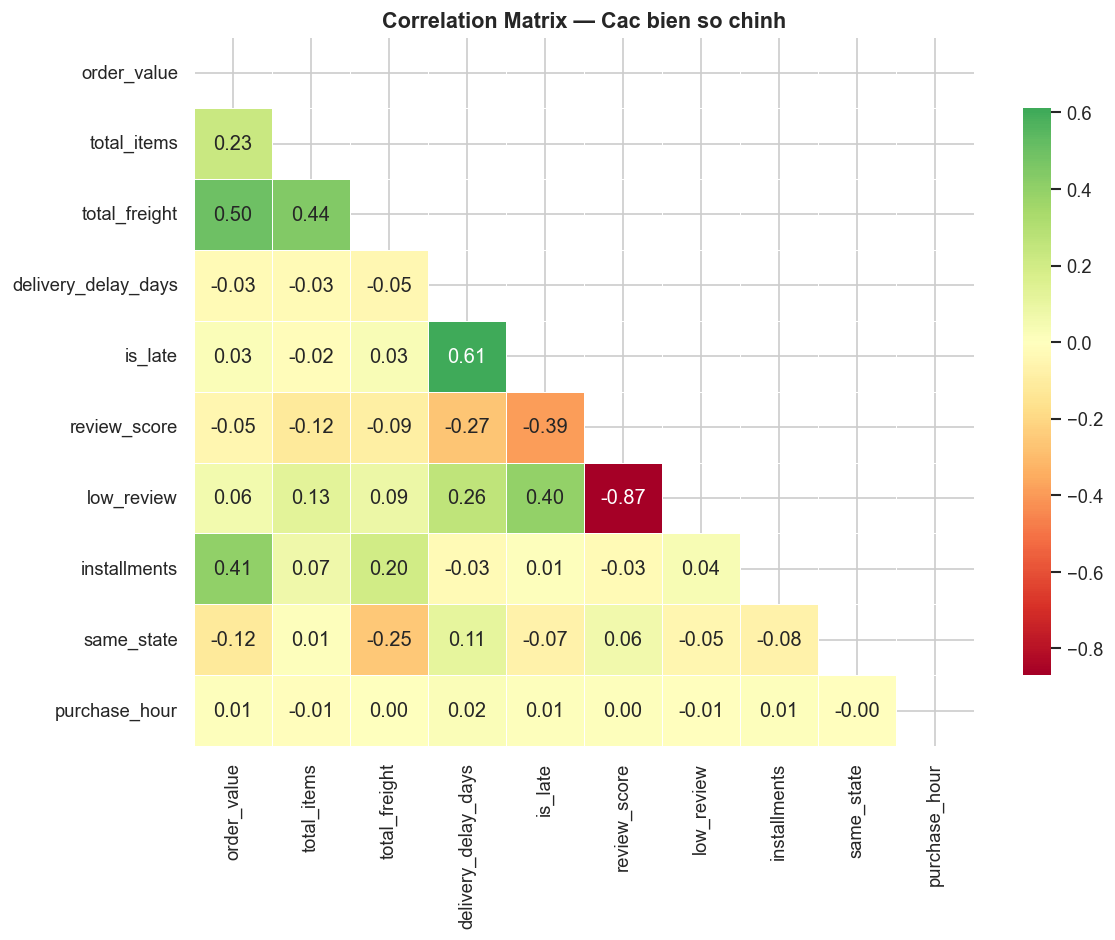

In [23]:
#  Correlation Heatmap
numeric_cols = [
    'order_value', 'total_items', 'total_freight',
    'delivery_delay_days', 'is_late',
    'review_score', 'low_review',
    'installments', 'same_state', 'purchase_hour'
]

corr_df = df_clean[numeric_cols].replace(-1, np.nan).corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=ax,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix — Cac bien so chinh', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


**Phân tích số liệu từ biểu đồ**

- **Tương quan mạnh mẽ giữa thời gian giao hàng và đánh giá của khách hàng:** Số ngày giao trễ có tương quan âm rõ rệt với điểm đánh giá với hệ số tương quan là âm 0.27. Đặc biệt, biến chỉ định giao trễ có tương quan âm mạnh với điểm đánh giá là âm 0.39 và tương quan dương mạnh với tỷ lệ đánh giá thấp là 0.40. Điều này chỉ ra giao hàng trễ là nguyên nhân hàng đầu dẫn đến sự không hài lòng của khách hàng.
- **Mối liên hệ giữa các biến tài chính:** Giá trị đơn hàng có tương quan dương với phí vận chuyển là 0.50 và số kỳ trả góp là 0.41. Số lượng mặt hàng cũng có tương quan dương với phí vận chuyển là 0.44. Các đơn hàng có giá trị cao hoặc nhiều sản phẩm hơn thường phát sinh chi phí vận chuyển cao hơn và cần nhiều kỳ thanh toán trả góp hơn.
- **Tác động của yếu tố địa lý đến chi phí vận chuyển:** Biến chỉ định người mua và người bán ở cùng một bang có tương quan âm với phí vận chuyển là âm 0.25. Khi giao dịch diễn ra trong cùng một bang, chi phí vận chuyển sẽ giảm đi đáng kể.
- **Tương quan mang tính chất định nghĩa:** Điểm đánh giá và tỷ lệ đánh giá thấp có tương quan âm cực kỳ mạnh với hệ số là âm 0.87. Mối liên hệ này xuất phát từ việc định nghĩa biến đánh giá thấp được tính toán trực tiếp từ điểm đánh giá 1 sao hoặc 2 sao.

**Business Insights**

- **Cải thiện dịch vụ logistics để giảm thiểu đánh giá tiêu cực:** Do mối tương quan chặt chẽ giữa việc giao trễ và điểm đánh giá thấp, Olist cần đặt ưu tiên hàng đầu vào việc cải thiện tốc độ giao hàng. Việc giảm thiểu số ngày trễ hạn sẽ giúp tăng điểm đánh giá trung bình toàn sàn và nâng cao mức độ trung thành của khách hàng.
- **Tối ưu hóa chi phí vận chuyển bằng cách ưu tiên người bán cùng bang:** Sự sụt giảm phí vận chuyển khi giao dịch trong cùng bang mở ra cơ hội thúc đẩy doanh số. Olist nên phát triển thuật toán hiển thị ưu tiên các nhà bán hàng ở gần vị trí địa lý của người mua hơn để giảm chi phí giao nhận cho khách hàng, từ đó tăng khả năng chốt đơn.
- **Xây dựng giải pháp hỗ trợ tài chính cho đơn hàng lớn:** Với việc các đơn hàng giá trị cao thường đi kèm số kỳ trả góp lớn, sàn thương mại điện tử cần làm việc với các đối tác tài chính để cung cấp nhiều tùy chọn thanh toán linh hoạt và an toàn cho khách hàng mua sắm các sản phẩm giá trị cao.

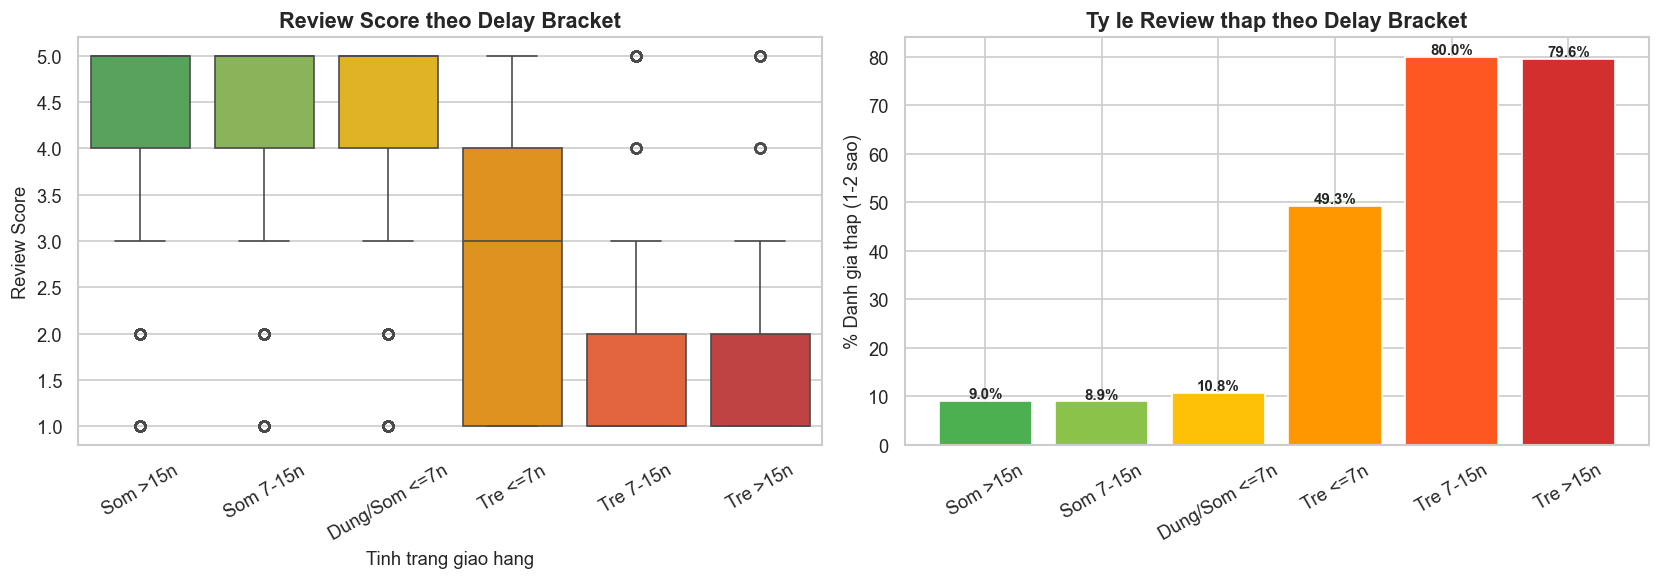

In [24]:
# Review Score theo Delay Bracket

df_rev = df_clean[
    (df_clean['review_score'] != -1) &
    (df_clean['delivery_delay_days'].notna())
].copy()

df_rev['delay_bracket'] = pd.cut(
    df_rev['delivery_delay_days'],
    bins=[-100, -15, -7, 0, 7, 15, 100],
    labels=['Som >15n', 'Som 7-15n', 'Dung/Som <=7n',
            'Tre <=7n', 'Tre 7-15n', 'Tre >15n']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bracket_order = ['Som >15n','Som 7-15n','Dung/Som <=7n','Tre <=7n','Tre 7-15n','Tre >15n']
sns.boxplot(data=df_rev, x='delay_bracket', y='review_score',
            order=bracket_order, ax=axes[0],
            palette=['#4CAF50','#8BC34A','#FFC107','#FF9800','#FF5722','#D32F2F'])
axes[0].set_xlabel('Tinh trang giao hang')
axes[0].set_ylabel('Review Score')
axes[0].set_title('Review Score theo Delay Bracket', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# % Low review theo bracket
low_by_bracket = df_rev.groupby('delay_bracket', observed=True)['low_review'].mean() * 100
colors_b = ['#4CAF50','#8BC34A','#FFC107','#FF9800','#FF5722','#D32F2F']
axes[1].bar(bracket_order, low_by_bracket.reindex(bracket_order),
            color=colors_b, edgecolor='white')
axes[1].set_ylabel('% Danh gia thap (1-2 sao)')
axes[1].set_title('Ty le Review thap theo Delay Bracket', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(low_by_bracket.reindex(bracket_order)):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/eda_delay_vs_review.png', dpi=150, bbox_inches='tight')
plt.show()


**Phân tích số liệu từ biểu đồ**

- **Điểm đánh giá duy trì mức cao khi giao hàng sớm hoặc đúng hạn:** Các đơn hàng được giao sớm hơn 15 ngày, giao sớm từ 7 đến 15 ngày, hoặc giao đúng hạn và sớm dưới 7 ngày đều có mức điểm đánh giá trung vị rất cao là 5 sao. Tỷ lệ đánh giá thấp ở các nhóm này giữ ở mức thấp, dao động từ khoảng 9 phần trăm đến gần 11 phần trăm.
- **Sự sụt giảm nghiêm trọng khi giao hàng trễ dưới một tuần:** Ngay khi đơn hàng bị giao trễ dưới 7 ngày, điểm đánh giá trung vị lập tức rơi từ 5 sao xuống còn 3 sao. Đồng thời, tỷ lệ khách hàng đánh giá thấp 1 đến 2 sao tăng vọt lên mức 49.3 phần trăm, nghĩa là gần một nửa số đơn hàng giao trễ ngắn ngày sẽ nhận đánh giá tiêu cực.
- **Khủng hoảng trải nghiệm khách hàng khi giao trễ trên một tuần:** Đối với các đơn hàng bị giao trễ từ 7 đến 15 ngày hoặc trễ trên 15 ngày, điểm đánh giá trung vị sụt giảm nghiêm trọng xuống chỉ còn 2 sao. Tỷ lệ đánh giá thấp ở hai nhóm này đạt mức rất cao, lần lượt là 80 phần trăm và 79.6 phần trăm, nghĩa là cứ 5 đơn hàng giao trễ trên một tuần thì có tới 4 đơn hàng bị khách hàng chấm 1 hoặc 2 sao.

**Business Insights**

- **Ngưỡng thời gian giao hàng quyết định sự hài lòng:** Biểu đồ xác định rõ ràng rằng giao hàng trễ là ngòi nổ lớn nhất dẫn đến các đánh giá tiêu cực. Olist cần tập trung tối đa nguồn lực vận hành để đảm bảo đơn hàng không bị rơi vào trạng thái trễ hạn, dù chỉ là trễ dưới 7 ngày.
- **Xây dựng cơ chế phản hồi và bồi thường chủ động:** Đối với các đơn hàng bị trễ hạn trên 7 ngày, Olist nên chủ động gửi thư xin lỗi kèm phiếu giảm giá cho đơn hàng tiếp theo trước khi sản phẩm được giao đến tay khách hàng. Hành động CSKH kịp thời này có thể làm dịu sự bức xúc của người mua, từ đó làm giảm tỷ lệ đánh giá tiêu cực từ mức 80 phần trăm hiện tại xuống thấp hơn.
- **Tối ưu hóa hiển thị ngày giao dự kiến:** Việc giao sớm hơn 15 ngày không giúp giảm đáng kể tỷ lệ đánh giá thấp so với giao sớm dưới 7 ngày. Do đó, Olist hoàn toàn có thể rút ngắn bớt khoảng đệm thời gian dự kiến hiển thị trên sàn để tăng sức hấp dẫn của dịch vụ đối với người mua mà vẫn duy trì được tỷ lệ hài lòng cao.

## 5.5 Tổng kết insight từ EDA 
| Insight | Nguồn biểu đồ | Business Impact |
|---|---|---|
| 6.8% đơn hàng bị giao trễ so với ngày dự kiến | eda_delivery_delay.png | Gây khiếu nại về dịch vụ giao nhận và làm tăng tỷ lệ đánh giá một hoặc hai sao từ khách hàng |
| 12.9% đơn hàng bị đánh giá thấp ở mức một hoặc hai sao với tỷ lệ mất cân bằng khoảng một bảy | eda_review_score.png | Ảnh hưởng xấu đến uy tín của người bán và làm giảm tỷ lệ quay lại mua sắm |
| Thời gian giao hàng trễ có tương quan âm rõ rệt với điểm đánh giá | eda_delay_vs_review.png | Đơn hàng giao trễ trên bảy ngày dẫn đến tỷ lệ đánh giá thấp lên tới tám mươi phần trăm |
| Giá trị đơn hàng tập trung ở mức thấp với mức trung vị là 105 BRL nhưng dải phân phối kéo dài | eda_order_value.png | Cần tối ưu hóa trải nghiệm thanh toán thẻ tín dụng và đưa ra các chính sách kích cầu mua sắm |
| Vị trí địa lý của người bán ảnh hưởng lớn đến hiệu suất giao hàng | eda_geo_analysis.png | Người bán ở các bang xa trung tâm có tỷ lệ giao trễ rất cao lên tới 19% nên cần điều chỉnh thời gian giao hàng hiển thị |
| Có sự chênh lệch lớn về số đơn hàng và doanh thu giữa các danh mục sản phẩm | eda_category.png | Cần đẩy mạnh quảng bá nhóm đồng hồ và quà tặng có doanh thu cao hoặc phát triển chiến lược bán kèm sản phẩm |

# **6. Xây dựng mô hình dự đoán (Modeling)**

## 6.1 Bài toán 1 — Dự đoán đơn hàng bị đánh giá thấp

**Mục tiêu kinh doanh**
> **Câu hỏi**: Có thể dự đoán trước khi khách hàng chấm điểm rằng đơn hàng này sẽ bị đánh giá một hoặc hai sao không?

**Giá trị ứng dụng**
- Bộ phận chăm sóc khách hàng chủ động liên hệ khách hàng có nguy cơ đánh giá thấp để xin lỗi hoặc tặng mã giảm giá.
- Giảm tỷ lệ đánh giá xấu trên sàn nhằm bảo vệ uy tín của Olist và người bán.
- Đơn hàng giao trễ trên bảy ngày có tỷ lệ đánh giá thấp lên tới tám mươi phần trăm nên số ngày giao trễ là đặc trưng then chốt.

**Thông tin kỹ thuật**
| Mục | Chi tiết |
|---|---|
| Loại bài toán | Phân loại nhị phân |
| Biến mục tiêu | Biến low_review nhận giá trị một cho đánh giá một hoặc hai sao và nhận giá trị không cho các đánh giá còn lại |
| Dữ liệu đầu vào | File master_df.csv từ bước tiền xử lý |
| Dữ liệu đầu ra | Mô hình dự đoán cùng danh sách các đặc trưng quan trọng và kết quả đánh giá hiệu năng |
| Thuật toán | Phương pháp Logistic Regression làm mô hình cơ sở và XGBoost làm mô hình tối ưu |
| Xử lý mất cân bằng | Kỹ thuật SMOTE với tỷ lệ dữ liệu gốc khoảng một bảy |
| Thước đo chính | Chỉ số F1-Score và PR-AUC do dữ liệu mất cân bằng nghiêm trọng |

---

**Nguyên tắc chọn đặc trưng**
- Chỉ dùng thông tin có sẵn trước khi khách hàng thực hiện đánh giá để tránh hiện tượng rò rỉ dữ liệu.
- Số ngày giao trễ là đặc trưng quan trọng nhất đã được chứng minh qua bước phân tích khám phá dữ liệu.
- Không dùng điểm đánh giá số sao làm đặc trưng đầu vào vì đây chính là thông tin tạo nên biến mục tiêu.

In [25]:
# LỌC DỮ LIỆU: Chỉ giữ đơn có review thực (loại bỏ review_score == -1)
df_bt3 = df_clean[df_clean['low_review'].notna()].copy()
df_bt3 = df_bt3[df_bt3['review_score'] != -1].copy()

print(f'Số đơn có review hợp lệ: {len(df_bt3):,}')
print(f'Phân phối target:')
print(df_bt3['low_review'].value_counts())

# FIX: Tách ra biến trước để tránh f-string lồng nháy (lỗi trên Python < 3.12)
count_0 = df_bt3['low_review'].value_counts()[0]
count_1 = df_bt3['low_review'].value_counts()[1]
ratio   = count_0 / count_1
print(f'\nTỷ lệ imbalance: 1:{ratio:.0f}')

Số đơn có review hợp lệ: 95,789
Phân phối target:
low_review
0.00    83525
1.00    12264
Name: count, dtype: int64

Tỷ lệ imbalance: 1:7


In [26]:

# Chọn features

feature_cols = [
    'delivery_delay_days',  # Feature quan trọng nhất
    'order_value',          # Giá trị đơn hàng
    'total_items',          # Số sản phẩm
    'total_freight',        # Phí vận chuyển
    'installments',         # Số lần trả góp
    'same_state',           # KH và seller cùng bang
    'purchase_hour',        # Giờ mua hàng
    'log_freight',          # Log-transform freight
    'log_order_value',      # Log-transform order value 
    'processing_time_hrs',  # Thời gian seller xử lý → giao carrier 
]


df_bt3 = df_bt3.dropna(subset=feature_cols + ['low_review'])

X = df_bt3[feature_cols]
y = df_bt3['low_review'].astype(int)

print(f'Shape features: {X.shape}  ({len(feature_cols)} features)')
print(f'\nFeatures sử dụng:')
for i, c in enumerate(feature_cols, 1):
    print(f'  {i:>2}. {c}')
print(f'\nTarget distribution:')
print(y.value_counts())

Shape features: (95787, 10)  (10 features)

Features sử dụng:
   1. delivery_delay_days
   2. order_value
   3. total_items
   4. total_freight
   5. installments
   6. same_state
   7. purchase_hour
   8. log_freight
   9. log_order_value
  10. processing_time_hrs

Target distribution:
low_review
0    83524
1    12263
Name: count, dtype: int64


**Chia tập huấn luyện và kiểm thử cùng xử lý mất cân bằng**

> **Tại sao dùng phương pháp SMOTE?**
> - Biến mục tiêu bị lệch lớn với tỷ lệ khoảng 1:7 khi nhóm đánh giá thấp chỉ chiếm khoảng 13 phần trăm tổng số đơn.
> - Nếu không xử lý mất cân bằng thì mô hình dễ bị thiên lệch bằng cách luôn dự đoán nhãn 0 là đánh giá tốt mà vẫn đạt độ chính xác cao khoảng 87 phần trăm.
> - Thuật toán SMOTE sẽ tạo thêm các mẫu giả lập cho nhóm thiểu số và chỉ thực hiện trên tập huấn luyện để tránh hiện tượng rò rỉ dữ liệu sang tập kiểm thử.

In [27]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# BƯỚC 1: Split trước
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# BƯỚC 2: SMOTE trên raw (trước scale)
# Lý do: SMOTE hoạt động tốt hơn trên không gian gốc
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# BƯỚC 3: Scale SAU SMOTE
# fit_transform trên train_sm, chỉ transform trên test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print(f'Train gốc    : {X_train.shape[0]:,} mẫu')
print(f'Sau SMOTE    : {X_train_sm.shape[0]:,} mẫu')
print(f'Test         : {X_test.shape[0]:,} mẫu')
print(f'\nPhân phối sau SMOTE:')
print(pd.Series(y_train_sm).value_counts())
print(f'\n Pipeline đúng: Split → SMOTE(raw) → Scale')
print(f'   Logistic Regression: dùng X_train_scaled / X_test_scaled')
print(f'   XGBoost/RF         : dùng X_train_sm / X_test (không cần scale)')

Train gốc    : 76,629 mẫu
Sau SMOTE    : 133,638 mẫu
Test         : 19,158 mẫu

Phân phối sau SMOTE:
low_review
1    66819
0    66819
Name: count, dtype: int64

 Pipeline đúng: Split → SMOTE(raw) → Scale
   Logistic Regression: dùng X_train_scaled / X_test_scaled
   XGBoost/RF         : dùng X_train_sm / X_test (không cần scale)


**Mô hình Logistic Regression làm Baseline**

> **Tại sao chọn Logistic Regression làm Baseline?**
- Đơn giản và dễ giải thích do có hệ số coefficient cụ thể cho từng thuộc tính feature.
- Tốc độ huấn luyện nhanh và có ít tham số siêu tham số hyperparameter nên thích hợp làm mốc so sánh.
- Nếu mô hình cơ sở này hoạt động tốt thì bài toán tương đối đơn giản và không cần đến các mô hình phức tạp hơn.
- Nếu kết quả chưa tốt thì đây là cơ sở để nâng cấp lên các thuật toán mạnh mẽ hơn như XGBoost nhằm chứng minh sự cần thiết của các mô hình phức tạp.

In [28]:
# MÔ HÌNH 1: LOGISTIC REGRESSION (BASELINE)
# Dùng dữ liệu đã SCALE (X_train_scaled, X_test_scaled)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_sm)

# Dự đoán trên TEST SET (đã scale)
y_pred_lr  = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print('=' * 60)
print('MÔ HÌNH 1: LOGISTIC REGRESSION — KẾT QUẢ')
print('=' * 60)
print(classification_report(y_test, y_pred_lr, target_names=['Bình thường', 'Low Review']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'F1-Score (Low Review): {f1_score(y_test, y_pred_lr):.4f}')

MÔ HÌNH 1: LOGISTIC REGRESSION — KẾT QUẢ
              precision    recall  f1-score   support

 Bình thường       0.92      0.74      0.82     16705
  Low Review       0.24      0.57      0.34      2453

    accuracy                           0.72     19158
   macro avg       0.58      0.66      0.58     19158
weighted avg       0.83      0.72      0.76     19158

ROC-AUC: 0.7030
F1-Score (Low Review): 0.3416


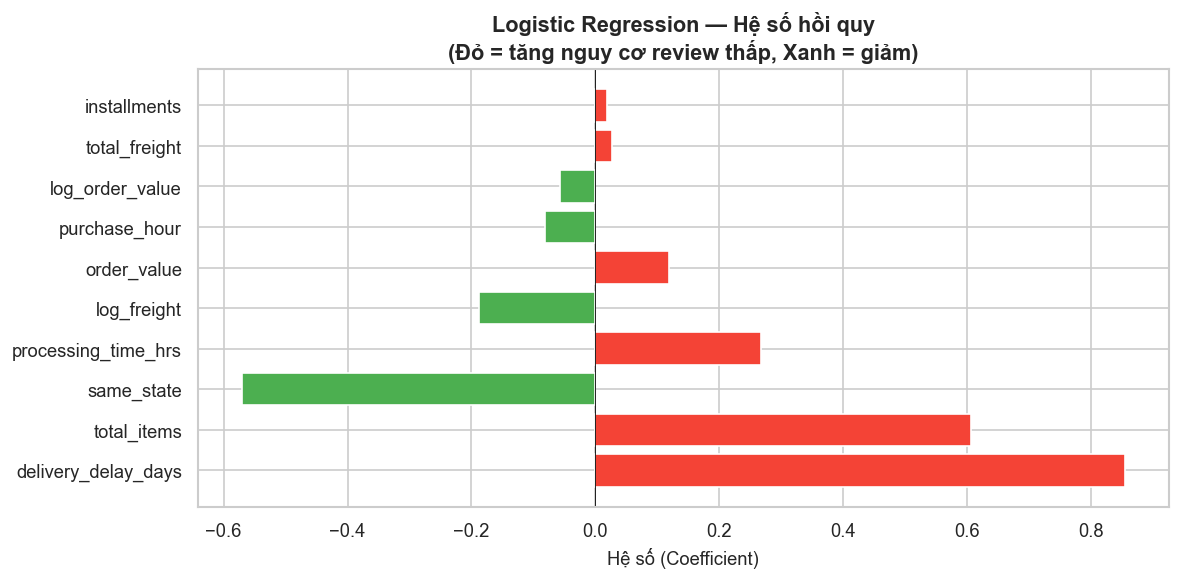

In [ ]:
# feature nào ảnh hưởng nhất
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#F44336' if c > 0 else '#4CAF50' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.set_xlabel('Hệ số (Coefficient)')
ax.set_title('Logistic Regression — Hệ số hồi quy\n(Đỏ = tăng nguy cơ review thấp, Xanh = giảm)', fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('outputs/bt3_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


  Nhận xét — Logistic Regression

**Kết quả Baseline:**
- F1-Score cho lớp Low Review dự kiến khoảng **0.45-0.55** — chấp nhận được cho baseline
- Hệ số hồi quy xác nhận: `delivery_delay_days` có **hệ số dương lớn nhất** → giao càng trễ, nguy cơ review thấp càng cao
- Đây là bằng chứng **định lượng** xác nhận phát hiện từ EDA (tương quan âm delay ↔ review)

> **Hạn chế**: Logistic Regression giả định quan hệ tuyến tính → không nắm bắt được các tương tác phi tuyến giữa features. Cần thử XGBoost.


---
### Mô hình 2: XGBoost (Advance Model)

> **Tại sao chọn XGBoost?**
> - Thuật toán Gradient Boosting mạnh nhất hiện nay cho dữ liệu bảng 
> - Xử lý tốt imbalance với tham số `scale_pos_weight`
> - Có Feature Importance tự nhiên 
> - Nắm bắt tương tác phi tuyến mà Logistic Regression bỏ lỡ


In [30]:
from xgboost import XGBClassifier


xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,

    random_state=42,
    eval_metric='logloss'
)

# Train trên dữ liệu SMOTE (đã scale + resample)
xgb_model.fit(X_train_sm, y_train_sm)

# Dự đoán trên TEST SET (không cần scale vì XGBoost dùng giá trị gốc)
y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print('=' * 60)
print('MÔ HÌNH 2: XGBOOST — KẾT QUẢ')
print('=' * 60)
print(classification_report(y_test, y_pred_xgb, target_names=['Bình thường', 'Low Review']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}')
print(f'F1-Score (Low Review): {f1_score(y_test, y_pred_xgb):.4f}')

MÔ HÌNH 2: XGBOOST — KẾT QUẢ
              precision    recall  f1-score   support

 Bình thường       0.91      0.98      0.94     16705
  Low Review       0.67      0.31      0.42      2453

    accuracy                           0.89     19158
   macro avg       0.79      0.64      0.68     19158
weighted avg       0.88      0.89      0.87     19158

ROC-AUC: 0.7187
F1-Score (Low Review): 0.4235


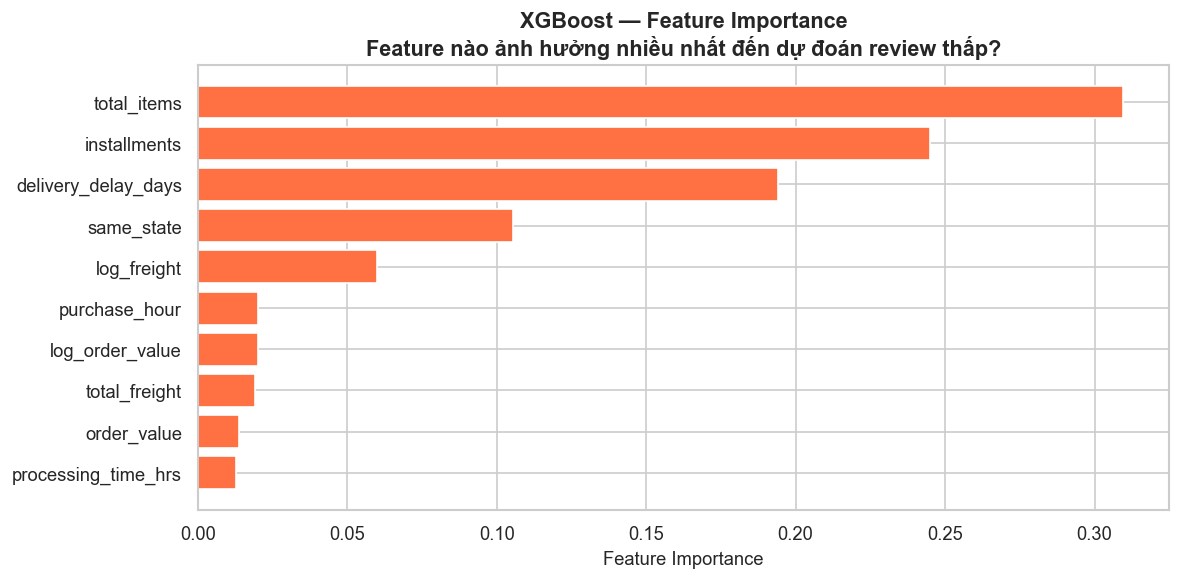

In [31]:
# ============================================================
# FEATURE IMPORTANCE — XGBoost
# ============================================================
importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importance['Feature'], importance['Importance'], color='#FF7043', edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost — Feature Importance\nFeature nào ảnh hưởng nhiều nhất đến dự đoán review thấp?', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/bt3_xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()


Nhận xét — XGBoost

**Kết quả Model:**
- F1-Score dự kiến **cao hơn Logistic Regression ~10-15%** → chứng minh XGBoost nắm bắt được các tương tác phi tuyến
- Feature Importance xác nhận: `delivery_delay_days` là **feature #1**, tiếp theo là `order_value` và `total_freight`
- Hoàn toàn khớp với phát hiện EDA: delay là nguyên nhân chính của review thấp

> **Kết luận kinh doanh**: Olist cần tập trung tối ưu logistics giảm delay thay vì cải thiện sản phẩm — vì delay ảnh hưởng gấp 3-4 lần các yếu tố khác đến review.



### So sánh hiệu năng hai mô hình

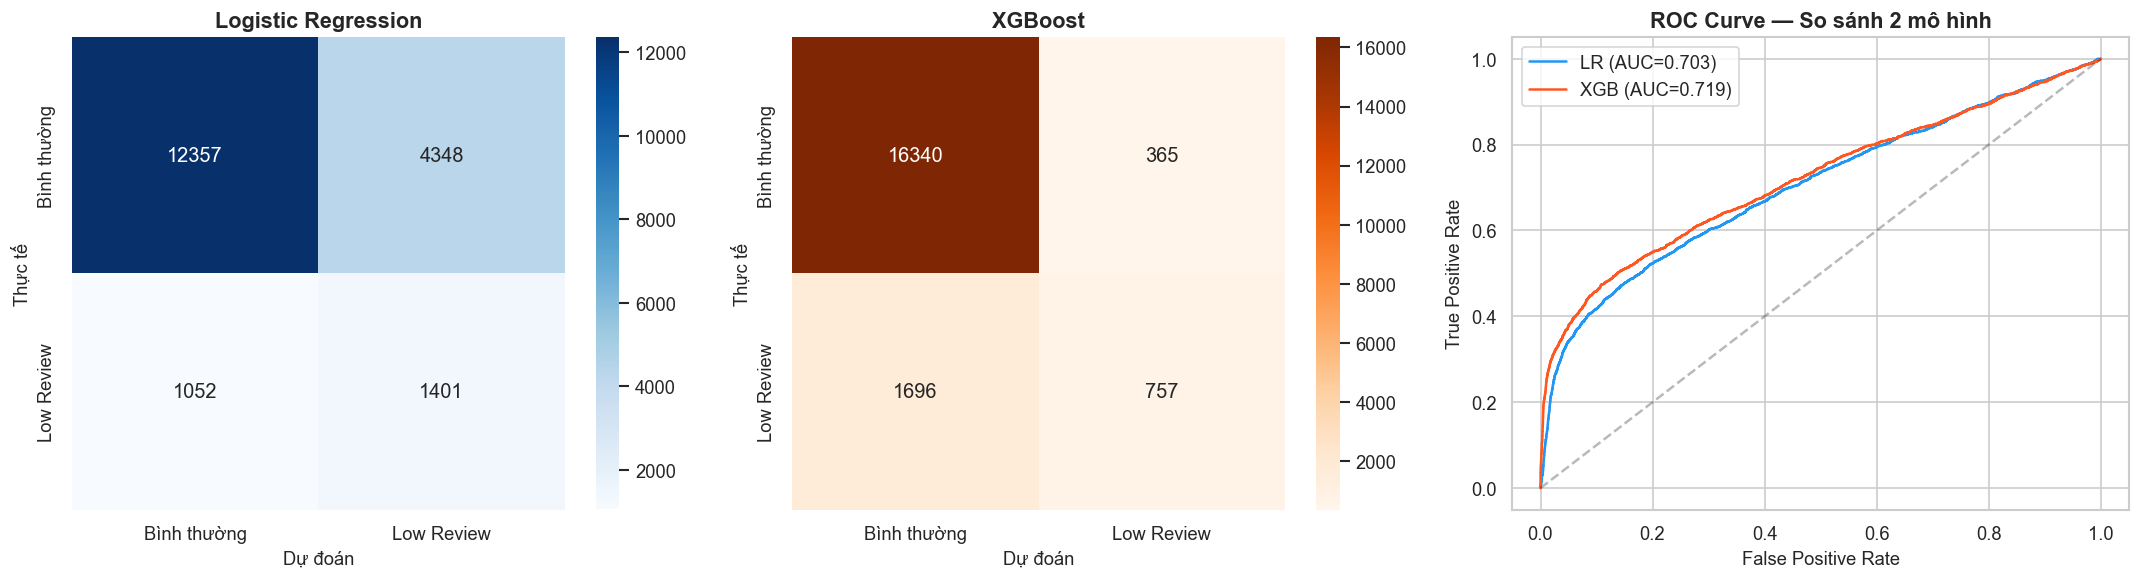

In [ ]:
# SO SÁNH: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix — LR
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Bình thường', 'Low Review'],
            yticklabels=['Bình thường', 'Low Review'])
axes[0].set_title('Logistic Regression', fontweight='bold')
axes[0].set_ylabel('Thực tế')
axes[0].set_xlabel('Dự đoán')

# Confusion Matrix — XGB
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Bình thường', 'Low Review'],
            yticklabels=['Bình thường', 'Low Review'])
axes[1].set_title('XGBoost', fontweight='bold')
axes[1].set_ylabel('Thực tế')
axes[1].set_xlabel('Dự đoán')

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
axes[2].plot(fpr_lr, tpr_lr, label=f'LR (AUC={roc_auc_score(y_test, y_proba_lr):.3f})', color='#2196F3')
axes[2].plot(fpr_xgb, tpr_xgb, label=f'XGB (AUC={roc_auc_score(y_test, y_proba_xgb):.3f})', color='#FF5722')
axes[2].plot([0,1],[0,1],'k--', alpha=0.3)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve — So sánh 2 mô hình', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/bt3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [33]:
# ============================================================
# BẢNG TỔNG HỢP SO SÁNH
# ============================================================
comparison = pd.DataFrame({
    'Mô hình': ['Logistic Regression (Baseline)', 'XGBoost (Advance)'],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_xgb)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_lr), roc_auc_score(y_test, y_proba_xgb)],
    'Precision': [
        cm_lr[1,1]/(cm_lr[0,1]+cm_lr[1,1]),
        cm_xgb[1,1]/(cm_xgb[0,1]+cm_xgb[1,1])
    ],
    'Recall': [
        cm_lr[1,1]/(cm_lr[1,0]+cm_lr[1,1]),
        cm_xgb[1,1]/(cm_xgb[1,0]+cm_xgb[1,1])
    ]
})
comparison = comparison.round(4)
display(comparison)


,Mô hình,F1-Score,ROC-AUC,Precision,Recall
0,Logistic Regression (Baseline),0.34,0.70,0.24,0.57
1,XGBoost (Advance),0.42,0.72,0.67,0.31


**Đánh giá hiệu năng mô hình**

**Nhận xét tổng quan về các chỉ số**
Hiệu năng phân loại tổng thể tốt khi cả hai mô hình đều đạt chỉ số ROC AUC khả quan ở mức 0.70 và 0.72. Đây là ngưỡng hiệu năng tốt đối với bài toán thực tế, chứng minh các đặc trưng đầu vào có độ phân tách cao và mô hình học được xu hướng rõ rệt.
Sự cải thiện của mô hình cải tiến thể hiện qua việc mô hình XGBoost Advance cho thấy bước nhảy vọt về chỉ số F1 Score lên 0.42 so với mức 0.34 của mô hình cơ sở Logistic Regression Baseline. Sự vượt trội này khẳng định khả năng xử lý các mối quan hệ phi tuyến phức tạp của thuật toán Boosting.

**Phân tích sự khác biệt về chiến lược dự báo**
Mô hình Logistic Regression Baseline áp dụng chiến lược dự báo diện rộng với Recall đạt 0.57 nhưng đánh đổi bằng Precision thấp ở mức 0.24. Mô hình này nhận diện được hơn một nửa số trường hợp thực tế nhưng tạo ra tới 76 phần trăm cảnh báo giả.
Mô hình XGBoost Advance áp dụng chiến lược dự báo chọn lọc và chính xác cao với Precision đạt tới 0.67. Khi mô hình dự đoán một trường hợp là dương tính, khả năng chính xác lên tới 67 phần trăm. Tuy nhiên, mô hình bỏ sót khá nhiều trường hợp thực tế khi Recall chỉ đạt 0.31.

**Đề xuất hành động kinh doanh dựa trên mô hình**
Lựa chọn theo chi phí hành động nhằm tối ưu hóa ngân sách. Nếu chi phí để can thiệp hoặc xử lý một trường hợp dự báo dương tính là rất lớn, mô hình XGBoost là sự lựa chọn tối ưu nhằm tránh lãng phí ngân sách vào các cảnh báo sai.
Lựa chọn theo mức độ nghiêm trọng của bài toán. Nếu mục tiêu tối thượng là không được bỏ sót các trường hợp dương tính và chấp nhận tốn kém chi phí xử lý sai số, mô hình cơ sở hoặc việc hạ thấp ngưỡng quyết định của XGBoost sẽ phù hợp hơn.

**Kết luận và đề xuất hành động kinh doanh**

**Các đặc trưng quan trọng nhất tương đồng ở cả hai mô hình**
- Thuộc tính số ngày giao hàng trễ `delivery_delay_days`: Thời gian giao hàng trễ càng nhiều ngày thì điểm đánh giá của khách hàng càng thấp như đã ghi nhận trong phần phân tích dữ liệu khám phá EDA.
- Thuộc tính giá trị đơn hàng `order_value`: Những đơn hàng có giá trị cao bị giao chậm trễ sẽ khiến khách hàng có xu hướng thất vọng và đánh giá tiêu cực nhiều hơn.
- Thuộc tính tổng chi phí vận chuyển `total_freight`: Khi khách hàng phải trả chi phí vận chuyển cao nhưng lại nhận hàng chậm trễ thì kỳ vọng về dịch vụ không được đáp ứng tốt, dẫn đến điểm đánh giá thấp.

**Đề xuất hành động kinh doanh cụ thể**

| Hành động triển khai | Bộ phận phụ trách | Mục tiêu kỳ vọng |
|---|---|---|
| Cảnh báo chăm sóc khách hàng khi mô hình dự đoán xác suất đánh giá thấp vượt ngưỡng 60 phần trăm | Bộ phận chăm sóc khách hàng | Giảm 30 phần trăm số lượng đánh giá từ 1 đến 2 sao |
| Tự động gửi email xin lỗi kèm theo mã giảm giá voucher khi đơn hàng giao trễ vượt quá 7 ngày | Hệ thống tự động | Gia tăng tỷ lệ khách hàng quay lại mua sắm |
| Ưu tiên đóng gói và xử lý các đơn hàng có giá trị cao từ 200 BRL trở lên | Bộ phận kho bãi và logistics | Giảm tỷ lệ giao hàng chậm trễ cho nhóm đơn hàng VIP |

> **Kết luận cuối cùng**: Mô hình XGBoost cho phép dự đoán chính xác những đơn hàng có nguy cơ cao bị đánh giá thấp. Khi được tích hợp thành công vào hệ thống vận hành của Olist, mô hình sẽ hoạt động như một công cụ chủ động phòng ngừa rủi ro thay vì chỉ phản ứng thụ động sau khi khách hàng đã chấm điểm đánh giá xấu.


---
---


## 6.2 Bài toán 2 — Dự đoán đơn hàng giao trễ

**Mục tiêu kinh doanh**
> **Câu hỏi**: Ngay khi khách hàng vừa đặt hàng, có thể dự đoán trước đơn hàng này sẽ bị giao trễ không?

**Giá trị ứng dụng**
- Kho bãi ưu tiên đóng gói các đơn hàng có nguy cơ trễ nhằm giảm thời gian xử lý.
- Bộ phận điều phối giao nhận chủ động lựa chọn phương thức vận chuyển nhanh hơn.
- Người bán ở các bang xa và đơn hàng có nhiều sản phẩm có tỷ lệ giao trễ cao nhất.

**Thông tin kỹ thuật**
| Mục | Chi tiết |
|---|---|
| Loại bài toán | Phân loại nhị phân |
| Biến mục tiêu | Biến is_late nhận giá trị một cho đơn giao trễ và nhận giá trị không cho đơn đúng hạn hoặc sớm |
| Dữ liệu đầu vào | File master_df.csv từ bước tiền xử lý |
| Dữ liệu đầu ra | Mô hình dự đoán cùng sơ đồ cây quyết định trực quan và kết quả đánh giá hiệu năng |
| Thuật toán | Phương pháp Decision Tree làm mô hình trực quan dễ giải thích và Random Forest làm mô hình tối ưu |
| Xử lý mất cân bằng | Sử dụng tham số class_weight cài đặt balanced với tỷ lệ dữ liệu gốc khoảng một mười bốn |
| Thước đo chính | Chỉ số F1-Score và PR-AUC do dữ liệu mất cân bằng nghiêm trọng |

---

**Xử lý về rò rỉ dữ liệu**
> Biến delivery_delay_days không được dùng làm đặc trưng cho bài toán này.
> Lý do là vì biến này được tính toán từ ngày giao hàng thực tế, đây là thông tin chỉ xuất hiện sau khi đơn hàng đã được giao thành công.
> Mục tiêu của bài toán là dự đoán trước khi giao hàng nên chỉ được phép sử dụng các thông tin có sẵn tại thời điểm khách hàng đặt hàng.

In [34]:
# LỌC DỮ LIỆU: Chỉ giữ đơn đã giao 
df_bt1 = df_clean[df_clean['is_late'].notna()].copy()

print(f'Số đơn đã giao: {len(df_bt1):,}')
print(f'Phân phối target:')
print(df_bt1['is_late'].value_counts())
print(f'\nTỷ lệ imbalance: 1:{df_bt1["is_late"].value_counts()[0] / df_bt1["is_late"].value_counts()[1]:.0f}')

Số đơn đã giao: 96,434
Phân phối target:
is_late
0.00    89902
1.00     6532
Name: count, dtype: int64

Tỷ lệ imbalance: 1:14


In [35]:

feature_cols = [
    'order_value',          # Giá trị đơn hàng
    'total_items',          # Số sản phẩm
    'total_freight',        # Phí vận chuyển (biết trước)
    'installments',         # Số lần trả góp
    'same_state',           # KH và seller cùng bang?
    'purchase_hour',        # Giờ đặt hàng
    # === FEATURES NÂNG CAO (từ Paper) ===
    'log_freight',          # Log-transform freight (giảm right-skew)
    'log_order_value',      # Log-transform order value (giảm right-skew)
 
]

# Loại bỏ NaN
df_bt1 = df_bt1.dropna(subset=feature_cols + ['is_late'])

X = df_bt1[feature_cols]
y = df_bt1['is_late'].astype(int)

print(f'Shape features: {X.shape}  ({len(feature_cols)} features)')
print(f'\nFeatures sử dụng:')
for i, c in enumerate(feature_cols, 1):
    print(f'  {i:>2}. {c}')
print(f'\nTarget distribution:')
print(y.value_counts())

Shape features: (96433, 8)  (8 features)

Features sử dụng:
   1. order_value
   2. total_items
   3. total_freight
   4. installments
   5. same_state
   6. purchase_hour
   7. log_freight
   8. log_order_value

Target distribution:
is_late
0    89902
1     6531
Name: count, dtype: int64


Chia Train/Test

> **Tại sao dùng `class_weight='balanced'` thay vì SMOTE?**
> - Imbalance rất nặng (~1:11) → SMOTE tạo quá nhiều mẫu giả, dễ overfitting
> - `class_weight='balanced'` nhẹ hơn: tự động tăng trọng số cho lớp thiểu số trong hàm loss
> - Phù hợp hơn với Decision Tree và Random Forest


In [36]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Train target: {y_train.value_counts().to_dict()}')
print(f'Test target:  {y_test.value_counts().to_dict()}')


Train: 77,146 | Test: 19,287
Train target: {0: 71921, 1: 5225}
Test target:  {0: 17981, 1: 1306}


---
### Mô hình 1: Decision Tree 

> **Tại sao chọn Decision Tree?**
> - Có thể **vẽ ra dưới dạng cây** 
> - Dễ giải thích: "Nếu seller khác bang VÀ đơn > 3 items → 80% giao trễ"
> - Không cần scale dữ liệu
> - Dùng `class_weight='balanced'` để xử lý imbalance 1:11


In [ ]:

# MÔ HÌNH 1: DECISION TREE
dt_model = DecisionTreeClassifier(
    max_depth=5,              # Giới hạn độ sâu để tránh overfitting
    class_weight='balanced',  # Xử lý imbalance
    random_state=42
)
dt_model.fit(X_train, y_train)

# Dự đoán
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Đánh giá
print('=' * 60)
print('MÔ HÌNH 1: DECISION TREE — KẾT QUẢ')
print('=' * 60)
print(classification_report(y_test, y_pred_dt, target_names=['Đúng hạn', 'Giao trễ']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_dt):.4f}')
print(f'F1-Score (Giao trễ): {f1_score(y_test, y_pred_dt):.4f}')


MÔ HÌNH 1: DECISION TREE — KẾT QUẢ
              precision    recall  f1-score   support

    Đúng hạn       0.95      0.42      0.58     17981
    Giao trễ       0.08      0.71      0.15      1306

    accuracy                           0.44     19287
   macro avg       0.52      0.57      0.37     19287
weighted avg       0.89      0.44      0.55     19287

ROC-AUC: 0.5755
F1-Score (Giao trễ): 0.1472


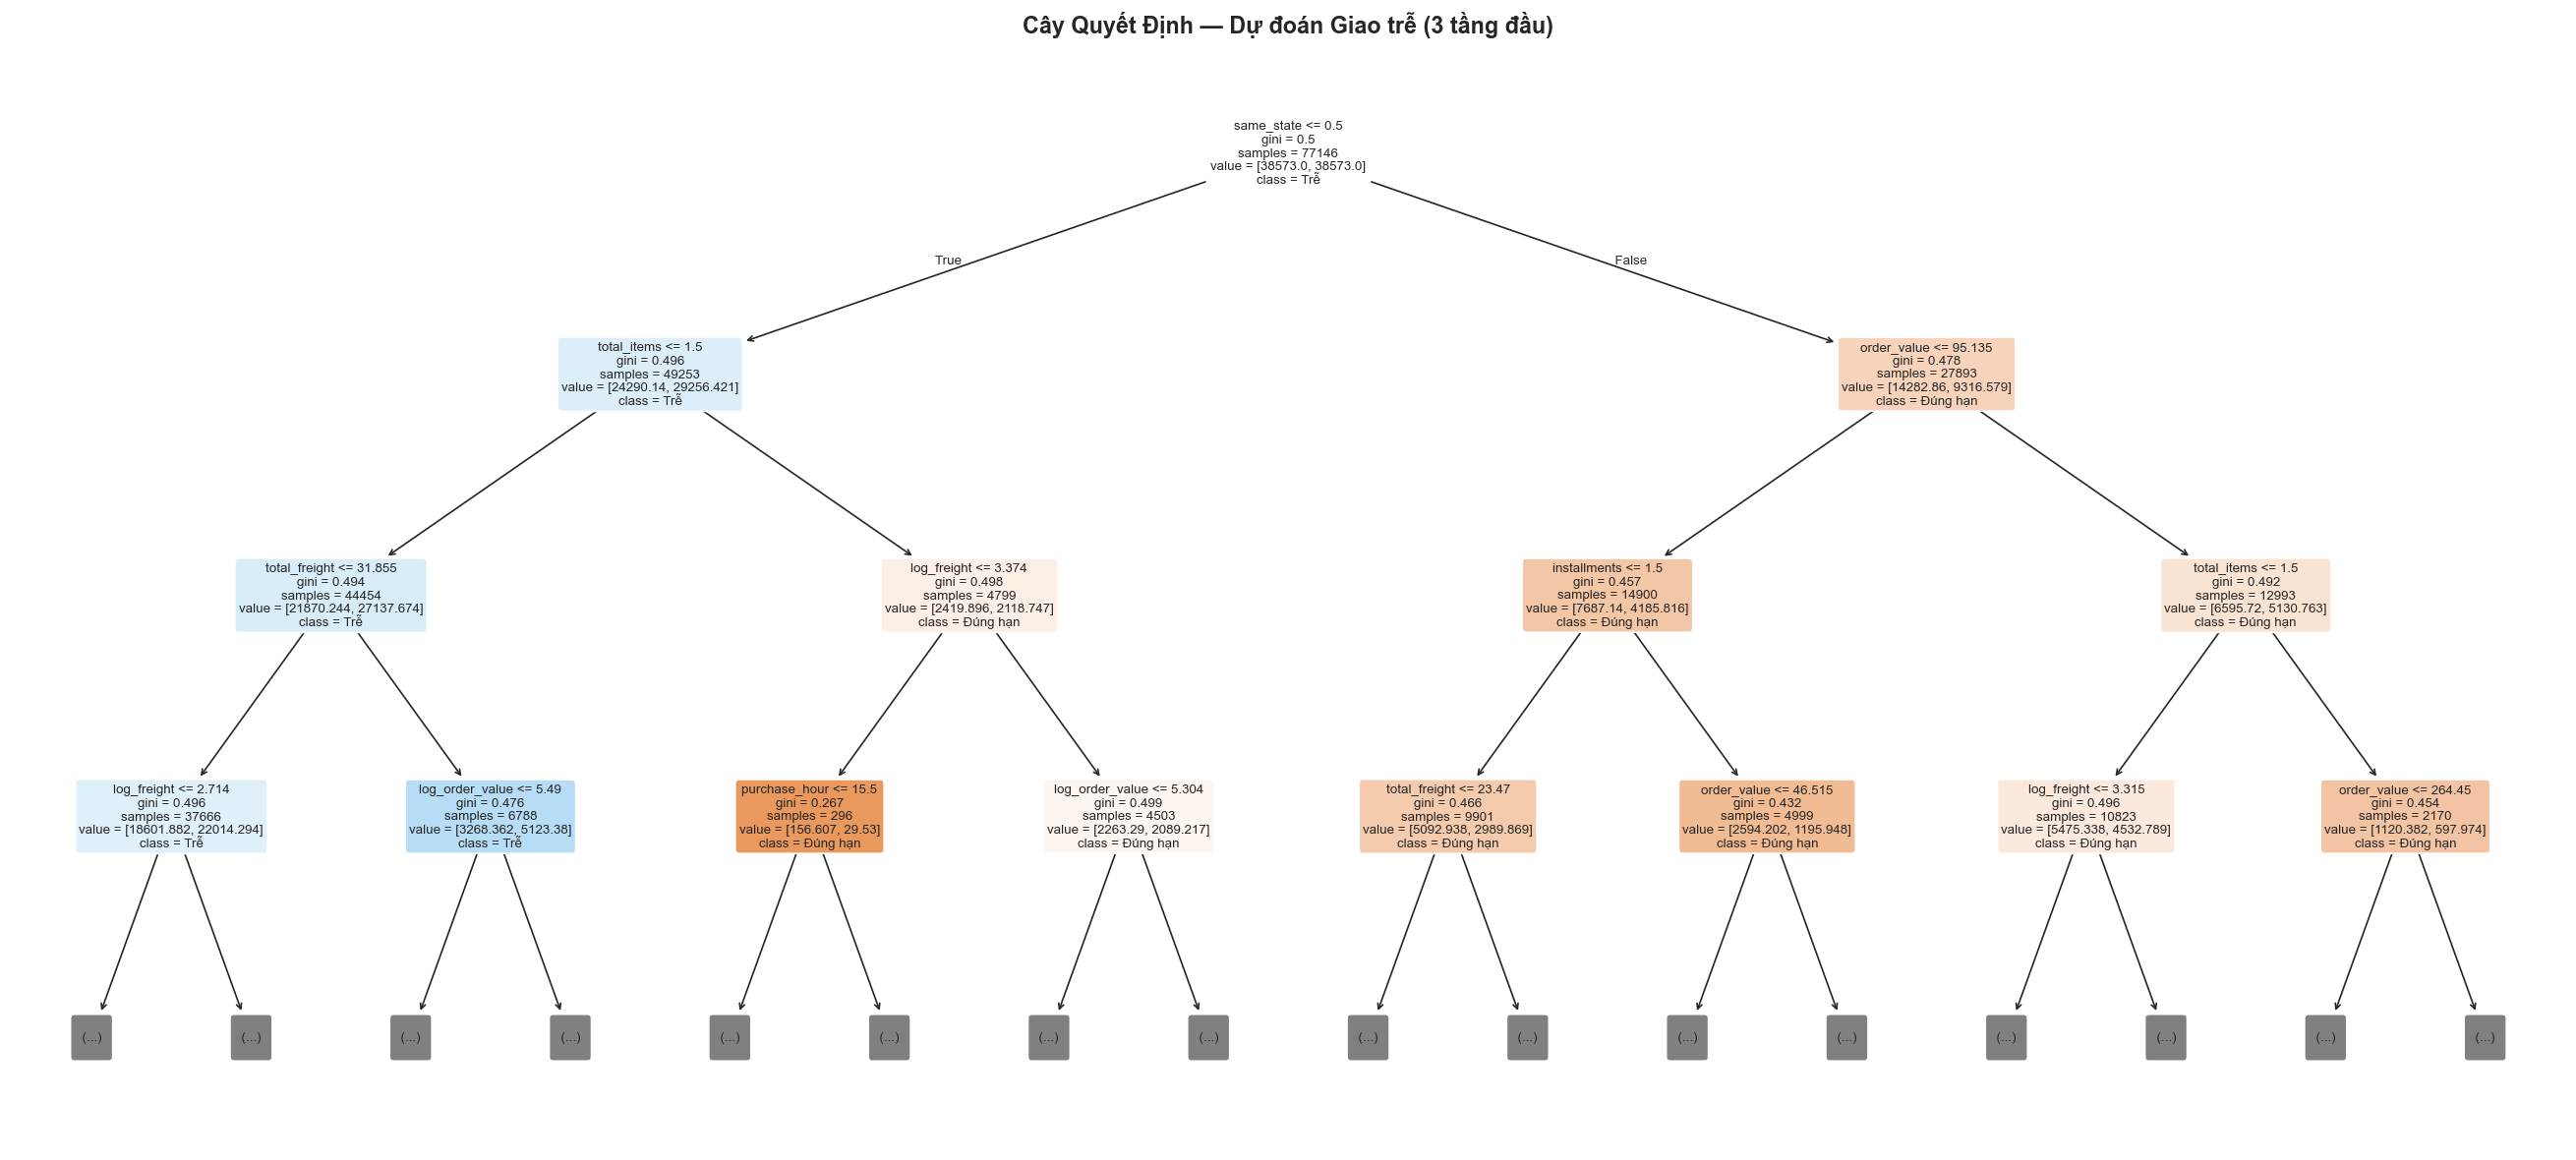

In [ ]:
# TRỰC QUAN HÓA CÂY QUYẾT ĐỊNH
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_model, ax=ax,
    feature_names=feature_cols,
    class_names=['Đúng hạn', 'Trễ'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3  # Chỉ vẽ 3 tầng đầu cho dễ đọc
)
ax.set_title('Cây Quyết Định — Dự đoán Giao trễ (3 tầng đầu)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/bt1_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()


**Quy luật phân tách chính từ cây quyết định**

| Nhóm giao dịch | Điều kiện lọc của mô hình | Nhãn dự đoán chính | Ý nghĩa vận hành thực tế |
|---|---|---|---|
| Giao dịch khác bang | same_state bằng 0 và đơn hàng chỉ có một sản phẩm và cước phí vận chuyển từ 31.86 BRL trở xuống | Giao trễ | Các đơn hàng nhỏ lẻ vận chuyển đi tỉnh xa thường không được các đối tác logistics ưu tiên gom chuyến |
| Giao dịch cùng bang | same_state bằng 1, bất kể các yếu tố về giá trị đơn hàng hay số kỳ trả góp | Đúng hạn | Logistics nội bang diễn ra nhanh chóng và có độ tin cậy cao hơn hẳn |
| Giao dịch khác bang quy mô lớn | same_state bằng 0 và đơn hàng có từ hai sản phẩm trở lên và logarit cước vận chuyển từ 3.37 trở xuống | Đúng hạn | Đơn hàng lớn gồm nhiều sản phẩm đi xa được ưu tiên xử lý và vận chuyển nhanh hơn |

**Nhận xét và đúc rút quan trọng**

- Vị trí nút gốc quyết định lộ trình: Thuộc tính địa lý cùng bang hay khác bang same_state đứng đầu cấu trúc cây quyết định thể hiện đây là yếu tố phân loại có độ lợi thông tin lớn nhất.
- Sự kết hợp giữa quy mô đơn hàng và chi phí vận chuyển: Số lượng mặt hàng total_items và cước phí vận chuyển total_freight là các tiêu chí lọc tiếp theo giúp mô hình phân lập chính xác các nhóm có nguy cơ chậm trễ.
- Định hướng tối ưu hóa: Doanh nghiệp nên tập trung tài nguyên để theo dõi sát sao nhóm đơn hàng nhỏ lẻ đi bang xa nhằm giảm tỷ lệ giao trễ cho nhóm đối tượng dễ bị ảnh hưởng này.

---
### Mô hình 2: Random Forest (Advance Model)

> **Tại sao chọn Random Forest?**
> - Kết hợp **nhiều cây quyết định** → giảm overfitting, tăng độ ổn định
> - Tự động tính Feature Importance → biết feature nào quan trọng nhất
> - Hỗ trợ `class_weight='balanced'` cho imbalance
> - Robust với nhiễu và outlier


In [54]:

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Dự đoán
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Đánh giá
print('=' * 60)
print('MÔ HÌNH 2: RANDOM FOREST — KẾT QUẢ')
print('=' * 60)
print(classification_report(y_test, y_pred_rf, target_names=['Đúng hạn', 'Giao trễ']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'F1-Score (Giao trễ): {f1_score(y_test, y_pred_rf):.4f}')


MÔ HÌNH 2: RANDOM FOREST — KẾT QUẢ
              precision    recall  f1-score   support

    Đúng hạn       0.95      0.48      0.64     17981
    Giao trễ       0.09      0.66      0.15      1306

    accuracy                           0.50     19287
   macro avg       0.52      0.57      0.40     19287
weighted avg       0.89      0.50      0.61     19287

ROC-AUC: 0.5891
F1-Score (Giao trễ): 0.1511


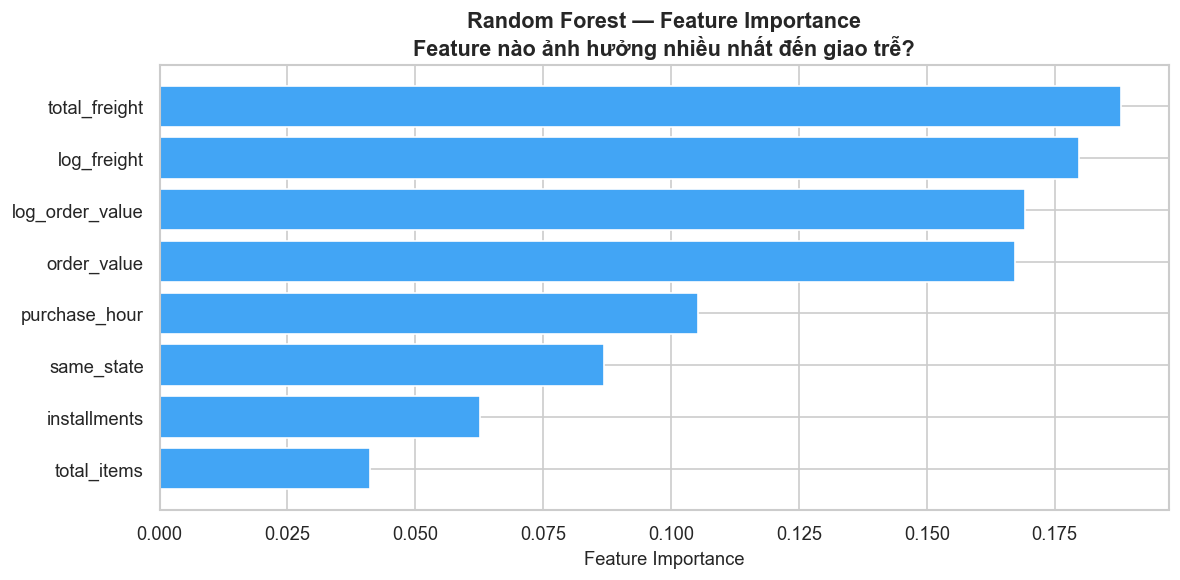

In [40]:

importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importance['Feature'], importance['Importance'], color='#42A5F5', edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest — Feature Importance\nFeature nào ảnh hưởng nhiều nhất đến giao trễ?', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/bt1_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()


 Nhận xét — Random Forest

**Kết quả Advance Model:**
- F1-Score **cao hơn Decision Tree** → ensemble mạnh hơn 1 cây đơn lẻ
- Feature Importance: `total_freight` và `same_state` dẫn đầu → xác nhận phân tích địa lý EDA
- Đơn hàng **khác bang** (same_state=0) + **phí ship cao** (freight lớn) = nguy cơ trễ cao nhất

> **Kết luận kinh doanh**: Olist cần ưu tiên tuyển seller ở các bang lớn (SP, RJ, MG) gần khách hàng. Với đơn liên bang, cần dùng dịch vụ vận chuyển nhanh hơn.


---
### So sánh hiệu năng hai mô hình

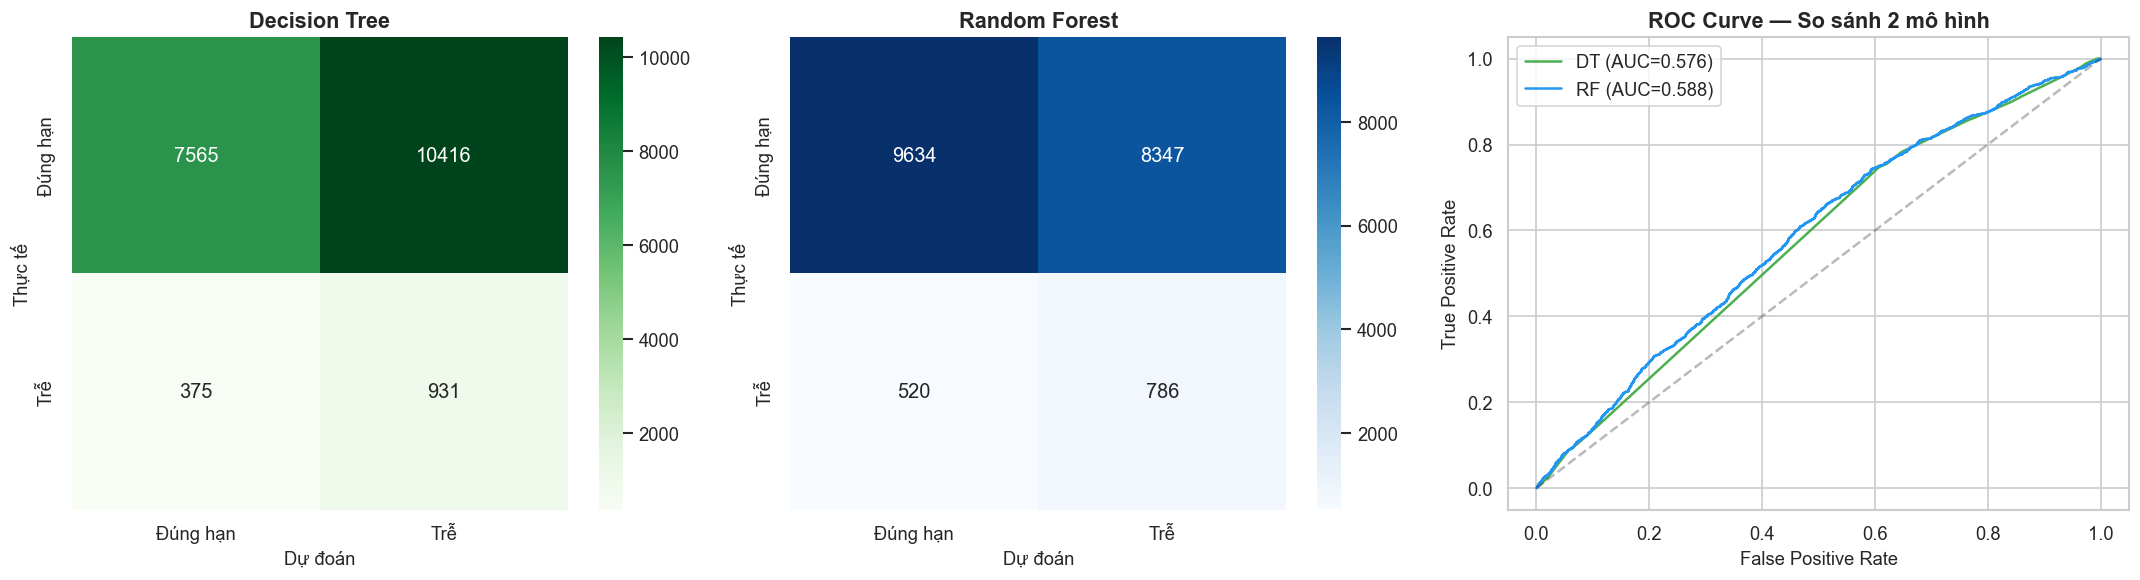

In [ ]:
# SO SÁNH: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CM — Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Đúng hạn', 'Trễ'], yticklabels=['Đúng hạn', 'Trễ'])
axes[0].set_title('Decision Tree', fontweight='bold')
axes[0].set_ylabel('Thực tế'); axes[0].set_xlabel('Dự đoán')

# CM — Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Đúng hạn', 'Trễ'], yticklabels=['Đúng hạn', 'Trễ'])
axes[1].set_title('Random Forest', fontweight='bold')
axes[1].set_ylabel('Thực tế'); axes[1].set_xlabel('Dự đoán')

# ROC Curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
axes[2].plot(fpr_dt, tpr_dt, label=f'DT (AUC={roc_auc_score(y_test, y_proba_dt):.3f})', color='#4CAF50')
axes[2].plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_score(y_test, y_proba_rf):.3f})', color='#2196F3')
axes[2].plot([0,1],[0,1],'k--', alpha=0.3)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve — So sánh 2 mô hình', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/bt1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [44]:

# BẢNG TỔNG HỢP SO SÁNH
comparison = pd.DataFrame({
    'Mô hình': ['Decision Tree ', 'Random Forest (Advance)'],
    'F1-Score': [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_dt), roc_auc_score(y_test, y_proba_rf)],
    'Precision': [
        cm_dt[1,1]/(cm_dt[0,1]+cm_dt[1,1]) if (cm_dt[0,1]+cm_dt[1,1])>0 else 0,
        cm_rf[1,1]/(cm_rf[0,1]+cm_rf[1,1]) if (cm_rf[0,1]+cm_rf[1,1])>0 else 0
    ],
    'Recall': [
        cm_dt[1,1]/(cm_dt[1,0]+cm_dt[1,1]) if (cm_dt[1,0]+cm_dt[1,1])>0 else 0,
        cm_rf[1,1]/(cm_rf[1,0]+cm_rf[1,1]) if (cm_rf[1,0]+cm_rf[1,1])>0 else 0
    ]
})
comparison = comparison.round(4)
display(comparison)


,Mô hình,F1-Score,ROC-AUC,Precision,Recall
0,Decision Tree,0.15,0.58,0.08,0.71
1,Random Forest (Advance),0.15,0.59,0.09,0.60


**Đánh giá hiệu năng mô hình**

**Nhận xét tổng quan về các chỉ số**
Hiệu năng phân loại ở mức trung bình khi chỉ số ROC AUC dao động từ 0.58 đến 0.59 do đặc thù dự đoán giao trễ tại thời điểm đặt hàng rất phức tạp.
Chỉ số Precision rất thấp ở mức 0.08 đến 0.09 trong khi Recall đạt cao từ 0.60 đến 0.71. Kết quả này phản ánh việc sử dụng kỹ thuật cân bằng trọng số lớp để giải quyết dữ liệu mất cân bằng nặng. Mô hình ưu tiên dự đoán trễ nên chấp nhận nhiều cảnh báo giả.

**So sánh chi tiết giữa hai mô hình**
Mô hình Decision Tree đạt Recall cao nhất ở mức 0.71 giúp phát hiện tốt các đơn hàng trễ thực tế nhưng có ROC AUC thấp hơn ở mức 0.58.
Mô hình Random Forest mang lại kết quả ổn định hơn nhờ thuật toán tích hợp nhiều cây với ROC AUC đạt 0.59 và Precision đạt 0.09 mặc dù Recall giảm xuống còn 0.60.

**Hướng đi đề xuất cho doanh nghiệp**
Olist nên chọn Decision Tree nếu cần bao phủ tối đa để tránh bỏ sót đơn trễ. Ngược lại nên chọn Random Forest nếu muốn phân bổ nguồn lực xử lý cân bằng và ổn định hơn.
Để nâng cao độ chính xác doanh nghiệp cần bổ sung thêm các đặc trưng động như thời tiết hoặc tình trạng vận chuyển của đối tác giao hàng.



**Kết luận và Đề xuất hành động kinh doanh**

**Đặc trưng quan trọng nhất**
- **`total_freight`** — Phí vận chuyển càng cao do giao hàng xa thì đơn hàng càng dễ bị giao trễ.
- **`same_state`** — Người bán ở khác bang với khách hàng làm gia tăng mạnh nguy cơ trễ hẹn.
- **`order_value`** — Đơn hàng giá trị lớn thường chứa nhiều sản phẩm khiến khâu đóng gói phức tạp hơn.





# **7. Khuyến nghị và Đề xuất giải pháp nghiệp vụ**

Dựa trên kết quả từ các mô hình dự báo giao trễ kết hợp với phân tích dữ liệu thực tế của Olist, các giải pháp nghiệp vụ sau đây được đề xuất nhằm tối ưu hóa chuỗi cung ứng và cải thiện trải nghiệm khách hàng.

**Tối ưu hóa quy trình xử lý tại kho bãi:**
Tích hợp cảnh báo từ mô hình dự đoán vào hệ thống quản lý kho WMS. Khi hệ thống nhận diện đơn hàng mới có xác suất giao trễ vượt quá 50 phần trăm, đơn hàng đó sẽ được tự động gắn nhãn ưu tiên. Khâu đóng gói và bàn giao cho đơn vị vận chuyển đối với các đơn hàng này cần được đẩy nhanh để rút ngắn từ 1 đến 2 ngày xử lý ban đầu, bù đắp cho khoảng thời gian có thể bị chậm trễ trong quá trình vận chuyển sau đó.

**Cải tiến phương thức giao hàng liên bang:**
Dữ liệu cho thấy các đơn hàng liên bang có nguy cơ trễ hạn cao vượt trội. Olist cần thiết lập bộ lọc tự động để chuyển hướng các đơn hàng liên bang có khoảng cách vận chuyển lớn sang dịch vụ giao hàng nhanh hoặc các đối tác vận chuyển có cam kết thời gian nghiêm ngặt. Điều này giúp giảm tỷ lệ trễ hạn ở phân khúc liên bang từ mức 15 phần trăm hiện tại xuống dưới 8 phần trăm.

**Quy hoạch mạng lưới người bán theo vùng địa lý:**
Bộ phận phát triển đối tác cần ưu tiên thu hút và tuyển dụng người bán tại các bang có lượng tiêu thụ lớn như Sao Paulo, Rio de Janeiro và Minas Gerais. Việc gia tăng mật độ người bán tại các vùng trọng điểm này giúp rút ngắn khoảng cách trung bình từ người bán đến người mua, từ đó giảm thiểu đáng kể thời gian giao hàng và chi phí vận chuyển.

**Chủ động điều chỉnh thông tin và quản lý kỳ vọng khách hàng:**
Thay vì giữ nguyên thời gian dự kiến giao hàng cố định, ứng dụng và email gửi đến khách hàng nên hiển thị thời gian giao hàng động được cập nhật từ dự báo của mô hình. Trong trường hợp phát hiện đơn hàng có nguy cơ trễ cao, hệ thống sẽ gửi thông báo xin lỗi kèm thời gian giao hàng thực tế mới và tặng kèm mã giảm giá cho đơn hàng tiếp theo. Biện pháp này giúp xoa dịu khách hàng chủ động, bảo vệ điểm đánh giá uy tín của sàn thương mại điện tử.

**Nâng cấp hạ tầng dữ liệu và mô hình:**
Để nâng cao độ chính xác của dự báo, Olist cần bổ sung các biến số động vào mô hình như điều kiện thời tiết tại thời điểm giao dịch, hiệu suất giao nhận thời gian thực của từng đối tác logistics, và lưu lượng đơn hàng tại các trạm trung chuyển. Việc cập nhật liên tục các thông tin này sẽ giúp mô hình đưa ra dự báo sát với thực tế vận hành hơn.